# 08 - Target Comparison: Price vs Log-Price and Model Comparision

This notebook compares two modeling strategies for laptop price prediction:

- **Direct price modeling**: models trained on `target_price` (original price scale)
- **Log-price modeling**: models trained on `log_target_price` (log-transformed scale)

## Objective

Evaluate whether training on `log_target_price` yields better or worse predictions than training directly on `target_price`, when both are assessed on the **original price scale**.

## Key Principle

Final model selection is based on metrics evaluated on `target_price` scale after inverse-transforming `log_target_price` predictions. On this scale, MAE, RMSE, median absolute error, and max error are measured in million VND. Metrics computed directly on `log_target_price` scale are log-space diagnostics and must not be compared directly with price-scale metrics.

## Source of Data

This notebook loads saved artifacts from notebook `07_modeling`. Model retraining is only triggered if required artifacts are missing or inconsistent.


## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ── Configuration (must match notebook 07) ────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE = 0.20
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True
CLOSE_WIN_THRESHOLD = 0.02  # differences below 2% are treated as a close result

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed.csv'

ARTIFACT_DIR        = PROJECT_ROOT / 'artifacts' / 'modeling_level'
METRICS_DIR         = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR     = ARTIFACT_DIR / 'predictions'
MODELS_DIR          = ARTIFACT_DIR / 'models'
PLOTS_DIR           = ARTIFACT_DIR / 'plots'
COMPARISON_DIR      = ARTIFACT_DIR / 'target_comparison'

COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'DATA_PATH     : {DATA_PATH}')
print(f'ARTIFACT_DIR  : {ARTIFACT_DIR}')
print(f'COMPARISON_DIR: {COMPARISON_DIR}')

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "08a_target_and_model_comparison_level"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


PROJECT_ROOT  : Y:\Python\Laptop-Price-Prediction
DATA_PATH     : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
ARTIFACT_DIR  : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level
COMPARISON_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\target_comparison
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\08a_target_and_model_comparison_level
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\08a_target_and_model_comparison_level


## 2. Helper Functions

In [2]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y = np.asarray(y_pred_log, dtype=float)
    if method == 'log1p':
        y_price = np.expm1(y)
    elif method == 'log':
        y_price = np.exp(y)
    else:
        raise ValueError("method must be 'log1p' or 'log'")
    if CLIP_NEGATIVE_PREDICTIONS:
        y_price = np.maximum(y_price, 0.0)
    return y_price


def calculate_metrics(y_true, y_pred) -> Dict[str, float]:
    """Return a dict of regression metrics (price scale)."""
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    rmsle = np.sqrt(np.mean((np.log1p(np.maximum(yp, 0)) - np.log1p(np.maximum(yt, 0))) ** 2))
    return {
        'mae'                : mean_absolute_error(yt, yp),
        'rmse'               : root_mean_squared_error(yt, yp),
        'r2'                 : r2_score(yt, yp),
        'mape'               : mean_absolute_percentage_error(yt, yp),
        'median_absolute_error': median_absolute_error(yt, yp),
        'max_error'          : max_error(yt, yp),
        'rmsle'              : rmsle,
    }


def winner_lower(a, b, name_a='target_price', name_b='log_target_price'):
    """Return the name of the better option (lower is better)."""
    if b < a:
        return name_b
    elif a < b:
        return name_a
    return 'tie'


def winner_higher(a, b, name_a='target_price', name_b='log_target_price'):
    """Return the name of the better option (higher is better)."""
    if b > a:
        return name_b
    elif a > b:
        return name_a
    return 'tie'


def pct_diff(new_val, ref_val):
    """Percentage difference of new_val vs ref_val."""
    if ref_val == 0:
        return np.nan
    return (new_val - ref_val) / ref_val


print('Helper functions defined.')

Helper functions defined.


## 3. Load Artifacts from Notebook 07

We first inspect what CSV files are available in `metrics/` and `predictions/`, then load the most relevant ones. We validate that both `target_price` and `log_target_price` results are present.

In [3]:
# ── Discover available files ──────────────────────────────────────────────────
metrics_csvs     = sorted(METRICS_DIR.glob('*.csv'))
predictions_csvs = sorted(PREDICTIONS_DIR.glob('*.csv'))

print('=== Metrics files ===')
for f in metrics_csvs:
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in predictions_csvs:
    print(f'  {f.name}')

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv


In [4]:
# ── Load metrics ──────────────────────────────────────────────────────────────
METRICS_FILE_CANDIDATES = ['model_metrics.csv', 'metrics_df.csv', 'all_metrics.csv']
metrics_raw = None
selected_metrics_file = None

for candidate in METRICS_FILE_CANDIDATES:
    path = METRICS_DIR / candidate
    if path.exists():
        metrics_raw = pd.read_csv(path)
        selected_metrics_file = path
        break

# Fallback: try any CSV that contains both target values
if metrics_raw is None:
    for f in metrics_csvs:
        try:
            df_try = pd.read_csv(f)
            cols_lower = [c.lower() for c in df_try.columns]
            if any('target' in c for c in cols_lower) and any('model' in c for c in cols_lower):
                metrics_raw = df_try
                selected_metrics_file = f
                break
        except Exception:
            continue

if metrics_raw is None:
    raise FileNotFoundError(
        'No suitable metrics CSV found in ' + str(METRICS_DIR) +
        '. Please run notebook 07_modeling first to generate model_metrics.csv.'
    )

print(f'Loaded metrics from: {selected_metrics_file.name}')
print(f'Shape: {metrics_raw.shape}')
display(metrics_raw.head())

Loaded metrics from: model_metrics.csv
Shape: (16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.3709,5.4827,0.8870,0.3001,2.0150,36.6205,2.7868,0.0073
1,LightGBM,gradient_boosting,target_price,target_price,3.2904,5.4981,0.8864,0.2817,1.8933,39.6096,2.3375,0.0160
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2535,5.5300,0.8850,0.2627,1.8255,40.9106,2.6372,0.0149
3,Random Forest,tree_ensemble,target_price,target_price,3.4085,5.6870,0.8784,0.3021,1.9347,46.8513,2.7782,0.1352
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3370,5.7407,0.8761,0.2621,1.8086,43.0101,2.1606,0.0040


In [5]:
# ── Load predictions ──────────────────────────────────────────────────────────
PREDICTIONS_FILE_CANDIDATES = ['test_predictions.csv', 'predictions_df.csv', 'all_predictions.csv']
predictions_raw = None
selected_predictions_file = None

for candidate in PREDICTIONS_FILE_CANDIDATES:
    path = PREDICTIONS_DIR / candidate
    if path.exists():
        predictions_raw = pd.read_csv(path)
        selected_predictions_file = path
        break

if predictions_raw is None:
    for f in predictions_csvs:
        try:
            df_try = pd.read_csv(f)
            if any('pred' in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                selected_predictions_file = f
                break
        except Exception:
            continue

if predictions_raw is not None:
    print(f'Loaded predictions from: {selected_predictions_file.name}')
    print(f'Shape: {predictions_raw.shape}')
    display(predictions_raw.head())
else:
    print('WARNING: No predictions CSV found. Prediction-level analysis will be skipped.')

Loaded predictions from: test_predictions.csv
Shape: (1460, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,5.1244,5.0892,4.9042,5.1009,4.9049,5.0783,4.8954,5.0911,4.7560,4.3869,4.9560,5.7828,3.4152,3.6168,4.2923,3.7477
1,6004,37.4990,23.7416,20.8051,23.8598,20.7210,23.8524,20.3518,23.8449,20.4887,30.5577,29.9456,32.1394,32.5956,28.1858,31.3315,27.8331,27.6703
2,1768,27.4900,16.2240,13.5360,16.3601,13.5744,16.3640,13.4881,16.3678,13.4970,21.3259,19.5354,21.2413,19.3984,19.2228,18.4243,17.2601,16.3994
3,3360,7.8000,7.5580,6.5008,7.2300,6.4839,7.2376,6.5164,7.2294,6.4988,8.6322,8.1455,10.0000,10.0000,7.6635,7.5268,7.8962,7.2573
4,4700,12.9900,11.4057,9.5623,11.5210,9.5485,11.5308,9.7188,11.5252,9.6514,11.3804,11.4089,11.6000,11.5964,10.9634,11.0045,10.6491,10.5746


## 4. Artifact Validation

We verify that the metrics file contains the required columns and that both target types are present.

In [6]:
# ── Standardize column names ──────────────────────────────────────────────────
metrics_raw.columns = [
    c.strip().lower().replace(' ', '_').replace('-', '_')
    for c in metrics_raw.columns
]

# Rename known alias columns
rename_map = {
    'median_ae': 'median_absolute_error',
    'train_time_sec': 'training_time_seconds',
    'predict_time_sec': 'predict_time_seconds',
}
metrics_raw.rename(columns=rename_map, inplace=True)

print('Standardized columns:', metrics_raw.columns.tolist())

# ── Validate required columns ─────────────────────────────────────────────────
required_cols = ['model_name', 'target_used', 'mae', 'rmse', 'r2']
missing_cols = [c for c in required_cols if c not in metrics_raw.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in metrics: {missing_cols}')

# ── Validate both target types are present ────────────────────────────────────
targets_present = set(metrics_raw['target_used'].unique())
print(f'\nTargets present: {targets_present}')

has_price    = 'target_price'     in targets_present
has_logprice = 'log_target_price' in targets_present

if not has_price:
    print('WARNING: target_price results not found in metrics.')
if not has_logprice:
    print('WARNING: log_target_price results not found in metrics.')

if has_price and has_logprice:
    print('✓ Both target_price and log_target_price results found. Proceeding.')

Standardized columns: ['model_name', 'model_type', 'target_used', 'evaluation_scale', 'mae', 'rmse', 'r2', 'mape', 'median_absolute_error', 'max_error', 'training_time_seconds', 'predict_time_seconds']

Targets present: {'log_target_price', 'target_price'}
✓ Both target_price and log_target_price results found. Proceeding.


## 5. Clean and Standardize Metrics

We create a clean `metrics_df`, keep target labels identical to `target_price` and `log_target_price`, and separate subsets for each target type.

If `evaluation_scale = target_price`, MAE/RMSE/median absolute error/max error are in million VND. If `evaluation_scale = log_target_price`, metrics are in log space and are diagnostic only.


In [7]:
metrics_df = metrics_raw.copy()

# Ensure mape is expressed as a fraction (0-1 range), not percentage
if 'mape' in metrics_df.columns:
    if metrics_df['mape'].max() > 10:  # if stored as percentage like 23.4 instead of 0.234
        metrics_df['mape'] = metrics_df['mape'] / 100.0

# Keep display labels identical to the target column values so legends
# always use target_price and log_target_price in the same order.
TARGET_ORDER = ['target_price', 'log_target_price']
TARGET_PALETTE = {
    'target_price': '#4C72B0',
    'log_target_price': '#DD8452',
}
label_map = {target: target for target in TARGET_ORDER}
metrics_df['target_label'] = metrics_df['target_used'].map(label_map).fillna(metrics_df['target_used'])

price_metrics_df = metrics_df[metrics_df['target_used'] == 'target_price'].copy()
log_target_metrics_df = metrics_df[metrics_df['target_used'] == 'log_target_price'].copy()

print(f'Total rows: {len(metrics_df)}')
print(f'  target_price rows    : {len(price_metrics_df)}')
print(f'  log_target_price rows: {len(log_target_metrics_df)}')
print()

display_cols = ['model_name', 'target_used']
if 'evaluation_scale' in metrics_df.columns:
    display_cols.append('evaluation_scale')
display_cols += ['rmse', 'mae', 'r2']
display_cols += [c for c in ['mape', 'median_absolute_error', 'max_error'] if c in metrics_df.columns]

display(metrics_df[display_cols].sort_values('rmse').reset_index(drop=True))


Total rows: 16
  target_price rows    : 8
  log_target_price rows: 8



,model_name,target_used,evaluation_scale,rmse,mae,r2,mape,median_absolute_error,max_error
0,CatBoost,target_price,target_price,5.4827,3.3709,0.8870,0.3001,2.0150,36.6205
1,LightGBM,target_price,target_price,5.4981,3.2904,0.8864,0.2817,1.8933,39.6096
2,LightGBM,log_target_price,target_price,5.5300,3.2535,0.8850,0.2627,1.8255,40.9106
3,Random Forest,target_price,target_price,5.6870,3.4085,0.8784,0.3021,1.9347,46.8513
4,CatBoost,log_target_price,target_price,5.7407,3.3370,0.8761,0.2621,1.8086,43.0101
5,Random Forest,log_target_price,target_price,5.8456,3.4134,0.8715,0.2830,1.8778,49.3828
6,Extra Trees,target_price,target_price,5.9386,3.5442,0.8674,0.3095,2.0429,61.2973
7,Extra Trees,log_target_price,target_price,6.0317,3.5166,0.8632,0.2936,1.9810,62.7549
8,Linear Regression,log_target_price,target_price,6.9260,4.0736,0.8197,0.3191,2.1951,48.6459
9,Lasso,log_target_price,target_price,6.9425,4.0807,0.8188,0.3196,2.1852,50.2717


### Overall Model Ranking

This table ranks all model-target combinations on the original price scale after inverse-transforming predictions from `log_target_price` models.

The strongest results now come from the boosting models. **CatBoost with `target_price`** has the lowest RMSE (5.4827) and highest R² (0.8870), while **LightGBM with `log_target_price`** has the lowest MAE (3.2535) and the second-best MAPE (0.2627). **LightGBM with `target_price`** is also very close to the top: RMSE = 5.4981, MAE = 3.2904, R² = 0.8864.

This means the leading model family remains Boosting, but the winner depends on the metric. Direct price modeling is stronger for RMSE/R², while log-target modeling is stronger for MAE/MAPE. Linear models remain clearly weaker than tree-based models.

At this stage, the most defensible candidates are **LightGBM and CatBoost under both target strategies**, with final selection determined by the MAE-primary rule and RMSE tiebreaker.


## 6. Overall Ranking

We rank all model-target combinations by RMSE, MAE, MAPE, and R². The final ranking used for model selection is on `target_price` scale, after inverse-transforming any `log_target_price` predictions.


In [8]:
ranking_df = metrics_df.copy()

# Rank columns (lower is better for RMSE/MAE/MAPE, higher is better for R2)
ranking_df['rmse_rank'] = ranking_df['rmse'].rank(method='min').astype(int)
ranking_df['mae_rank']  = ranking_df['mae'].rank(method='min').astype(int)
ranking_df['r2_rank']   = ranking_df['r2'].rank(ascending=False, method='min').astype(int)

if 'mape' in ranking_df.columns:
    ranking_df['mape_rank'] = ranking_df['mape'].rank(method='min').astype(int)

rank_cols = ['model_name', 'target_used', 'rmse', 'rmse_rank', 'mae', 'mae_rank', 'r2', 'r2_rank']
if 'mape' in ranking_df.columns:
    rank_cols = rank_cols[:4] + ['mape', 'mape_rank'] + rank_cols[4:]

ranking_display = ranking_df[rank_cols].sort_values('rmse_rank').reset_index(drop=True)

print('=== Overall Ranking (sorted by RMSE) ===')
display(ranking_display)

# Save
ranking_display.to_csv(COMPARISON_DIR / 'target_comparison_overall_ranking.csv', index=False)
print(f'Saved: target_comparison_overall_ranking.csv')

=== Overall Ranking (sorted by RMSE) ===


,model_name,target_used,rmse,rmse_rank,mape,mape_rank,mae,mae_rank,r2,r2_rank
0,CatBoost,target_price,5.4827,1,0.3001,6,3.3709,4,0.8870,1
1,LightGBM,target_price,5.4981,2,0.2817,3,3.2904,2,0.8864,2
2,LightGBM,log_target_price,5.5300,3,0.2627,2,3.2535,1,0.8850,3
3,Random Forest,target_price,5.6870,4,0.3021,7,3.4085,5,0.8784,4
4,CatBoost,log_target_price,5.7407,5,0.2621,1,3.3370,3,0.8761,5
5,Random Forest,log_target_price,5.8456,6,0.2830,4,3.4134,6,0.8715,6
6,Extra Trees,target_price,5.9386,7,0.3095,8,3.5442,8,0.8674,7
7,Extra Trees,log_target_price,6.0317,8,0.2936,5,3.5166,7,0.8632,8
8,Linear Regression,log_target_price,6.9260,9,0.3191,9,4.0736,9,0.8197,9
9,Lasso,log_target_price,6.9425,10,0.3196,12,4.0807,11,0.8188,10


Saved: target_comparison_overall_ranking.csv


### Metric-Based Ranking Interpretation

The updated ranking no longer supports CatBoost `log_target_price` as the overall winner. **CatBoost with `target_price`** ranks first by RMSE and R², while **LightGBM with `log_target_price`** ranks first by MAE. Because the top MAE results are very close, the later balanced-selection rule uses RMSE as the tiebreaker.

Under that rule, **LightGBM with `target_price`** becomes the best balanced model: its MAE is within 2% of the best MAE result, but its RMSE is substantially better than the log-target alternatives.

For LightGBM, CatBoost, Random Forest, and Extra Trees, `log_target_price` generally improves MAPE and often MAE, but direct `target_price` is better for RMSE and R² among the strongest models. The linear models improve substantially with log-target in this level-encoded dataset, but they still rank below the boosting and tree ensemble models.

Overall, the main conclusion is a metric trade-off: **use direct price modeling when RMSE/R² matter most; use log-target evidence mainly to reduce typical or percentage-based error.**


## 7. Pairwise Target Comparison by Model

For each model that has results for both `target_price` and `log_target_price`, we compare metrics head-to-head on the original price scale. Lower is better for error metrics; higher is better for R². A difference below 2% is flagged as a close result.


In [9]:
pairwise_rows = []

for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if not {'target_price', 'log_target_price'}.issubset(pivot.index):
        continue  # skip if only one target is available

    p_rmse = pivot.loc['target_price', 'rmse']
    l_rmse = pivot.loc['log_target_price', 'rmse']
    p_mae = pivot.loc['target_price', 'mae']
    l_mae = pivot.loc['log_target_price', 'mae']
    p_r2 = pivot.loc['target_price', 'r2']
    l_r2 = pivot.loc['log_target_price', 'r2']

    rmse_pct = pct_diff(l_rmse, p_rmse)
    mae_pct = pct_diff(l_mae, p_mae)

    rmse_w = winner_lower(p_rmse, l_rmse)
    mae_w = winner_lower(p_mae, l_mae)
    r2_w = winner_higher(p_r2, l_r2)

    p_mape, l_mape, mape_w = None, None, None
    if 'mape' in pivot.columns:
        p_mape = pivot.loc['target_price', 'mape']
        l_mape = pivot.loc['log_target_price', 'mape']
        mape_w = winner_lower(p_mape, l_mape)

    mae_close = abs(mae_pct) < CLOSE_WIN_THRESHOLD
    rmse_close = abs(rmse_pct) < CLOSE_WIN_THRESHOLD

    if mae_close and rmse_close:
        rec = 'close_result'
    elif mae_w == 'log_target_price' and rmse_w == 'target_price':
        rec = 'metric_tradeoff'
    elif mae_w == 'target_price' and rmse_w == 'log_target_price':
        rec = 'metric_tradeoff'
    elif rmse_w == r2_w:
        rec = rmse_w
    else:
        rec = mae_w

    row = {
        'model_name': model_name,
        'target_price_rmse': p_rmse,
        'log_target_price_rmse': l_rmse,
        'rmse_winner': rmse_w,
        'rmse_abs_diff_log_vs_price': l_rmse - p_rmse,
        'rmse_pct_diff_log_vs_price': rmse_pct,
        'target_price_mae': p_mae,
        'log_target_price_mae': l_mae,
        'mae_winner': mae_w,
        'mae_abs_diff_log_vs_price': l_mae - p_mae,
        'mae_pct_diff_log_vs_price': mae_pct,
        'target_price_r2': p_r2,
        'log_target_price_r2': l_r2,
        'r2_winner': r2_w,
        'final_target_recommendation': rec,
    }

    if p_mape is not None:
        row['target_price_mape'] = p_mape
        row['log_target_price_mape'] = l_mape
        row['mape_winner'] = mape_w

    pairwise_rows.append(row)

pairwise_df = pd.DataFrame(pairwise_rows).sort_values('model_name').reset_index(drop=True)
display(pairwise_df)

pairwise_df.to_csv(COMPARISON_DIR / 'target_comparison_pairwise_by_model.csv', index=False)
print('Saved: target_comparison_pairwise_by_model.csv')


,model_name,target_price_rmse,log_target_price_rmse,rmse_winner,rmse_abs_diff_log_vs_price,rmse_pct_diff_log_vs_price,target_price_mae,log_target_price_mae,mae_winner,mae_abs_diff_log_vs_price,mae_pct_diff_log_vs_price,target_price_r2,log_target_price_r2,r2_winner,final_target_recommendation,target_price_mape,log_target_price_mape,mape_winner
0,CatBoost,5.4827,5.7407,target_price,0.2581,0.0471,3.3709,3.3370,log_target_price,-0.0339,-0.0101,0.8870,0.8761,target_price,metric_tradeoff,0.3001,0.2621,log_target_price
1,ElasticNet,7.9246,6.9437,log_target_price,-0.9810,-0.1238,4.7187,4.0807,log_target_price,-0.6380,-0.1352,0.7639,0.8188,log_target_price,log_target_price,0.4258,0.3194,log_target_price
2,Extra Trees,5.9386,6.0317,target_price,0.0931,0.0157,3.5442,3.5166,log_target_price,-0.0276,-0.0078,0.8674,0.8632,target_price,close_result,0.3095,0.2936,log_target_price
3,Lasso,7.9250,6.9425,log_target_price,-0.9825,-0.1240,4.7197,4.0807,log_target_price,-0.6390,-0.1354,0.7639,0.8188,log_target_price,log_target_price,0.4259,0.3196,log_target_price
4,LightGBM,5.4981,5.5300,target_price,0.0319,0.0058,3.2904,3.2535,log_target_price,-0.0369,-0.0112,0.8864,0.8850,target_price,close_result,0.2817,0.2627,log_target_price
5,Linear Regression,7.9334,6.9260,log_target_price,-1.0074,-0.1270,4.7241,4.0736,log_target_price,-0.6506,-0.1377,0.7634,0.8197,log_target_price,log_target_price,0.4274,0.3191,log_target_price
6,Random Forest,5.6870,5.8456,target_price,0.1586,0.0279,3.4085,3.4134,target_price,0.0049,0.0014,0.8784,0.8715,target_price,target_price,0.3021,0.2830,log_target_price
7,Ridge,7.9249,6.9602,log_target_price,-0.9647,-0.1217,4.7201,4.0868,log_target_price,-0.6333,-0.1342,0.7639,0.8179,log_target_price,log_target_price,0.4260,0.3193,log_target_price


Saved: target_comparison_pairwise_by_model.csv


### Pairwise Target Comparison Interpretation

This table compares each model trained on `target_price` against the same model trained on `log_target_price`, with all metrics evaluated on the original price scale.

For **CatBoost**, direct `target_price` now wins RMSE and R², while `log_target_price` wins MAE and MAPE. The log-target version reduces typical and percentage error, but its RMSE is about 4.7% worse, so it is not the best choice if large-error control is the priority.

For **LightGBM**, the target choice is very close on RMSE: direct price is only about 0.6% better, while log-target is better on MAE and MAPE. This makes LightGBM the cleanest case for carrying both target variants into later tuning.

For **Random Forest** and **Extra Trees**, direct price wins RMSE/R², while log-target improves MAPE and usually MAE. The Extra Trees RMSE gap is within the close-result threshold.

For the linear models in the level-encoded dataset, `log_target_price` improves RMSE, MAE, R², and MAPE versus direct price. Even so, their absolute performance remains weaker than the tree-based models.

Overall, `log_target_price` is helpful for MAE/MAPE, but it is not universally better. The strongest RMSE/R² evidence still favors direct price for the top boosting models.


## 8. Aggregate Comparison by Target Type

We summarize price-scale performance across all models for each target type, counting how many models each target wins for RMSE and MAE. These counts are diagnostic; final model selection still prioritizes the strongest model families and the balanced decision rule.


In [10]:
agg_dict = {
    'rmse': ['mean', 'median'],
    'mae' : ['mean', 'median'],
    'r2'  : ['mean'],
}
if 'mape' in metrics_df.columns:
    agg_dict['mape'] = ['mean']

summary_df = metrics_df.groupby('target_used').agg(agg_dict).round(4)
summary_df.columns = ['_'.join(c).strip() for c in summary_df.columns]
summary_df = summary_df.reset_index()

# ── Unweighted wins ───────────────────────────────────────────────────────────
if not pairwise_df.empty:
    rmse_wins = pairwise_df['rmse_winner'].value_counts()
    mae_wins  = pairwise_df['mae_winner'].value_counts()
    summary_df['rmse_wins'] = summary_df['target_used'].map(rmse_wins).fillna(0).astype(int)
    summary_df['mae_wins']  = summary_df['target_used'].map(mae_wins).fillna(0).astype(int)
    summary_df['n_models']  = len(pairwise_df)

    # ── Weighted wins: weight = (n-rank)/n, best model gets highest weight ────
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}

    for metric_col, label in [('rmse_winner', 'rmse_weighted_wins'),
                               ('mae_winner',  'mae_weighted_wins')]:
        weighted = (
            pairwise_df[['model_name', metric_col]]
            .assign(weight=pairwise_df['model_name'].map(model_weight))
            .groupby(metric_col)['weight'].sum()
            .round(3)
        )
        summary_df[label] = summary_df['target_used'].map(weighted).fillna(0).round(3)

    print('Model weights (higher = stronger model):')
    for m, w in sorted(model_weight.items(), key=lambda x: -x[1]):
        print(f'  {m:<22} weight={w:.3f}')
    print()

display(summary_df)

summary_df.to_csv(COMPARISON_DIR / 'target_comparison_summary_by_target.csv', index=False)
print('Saved: target_comparison_summary_by_target.csv')


Model weights (higher = stronger model):
  CatBoost               weight=1.000
  LightGBM               weight=0.875
  Random Forest          weight=0.750
  Extra Trees            weight=0.625
  Linear Regression      weight=0.500
  Lasso                  weight=0.375
  ElasticNet             weight=0.250
  Ridge                  weight=0.125



,target_used,rmse_mean,rmse_median,mae_mean,mae_median,r2_mean,mape_mean,rmse_wins,mae_wins,n_models,rmse_weighted_wins,mae_weighted_wins
0,log_target_price,6.3650,6.4789,3.7303,3.7951,0.8464,0.2973,4,7,8,1.2500,3.7500
1,target_price,6.7893,6.9316,4.0621,4.1314,0.8218,0.3623,4,1,8,3.2500,0.7500


Saved: target_comparison_summary_by_target.csv


### Aggregate Target-Level Comparison Interpretation

At the aggregate level, `log_target_price` has lower average RMSE, MAE, and MAPE because it improves the weaker linear models substantially and wins MAE for 7 out of 8 paired models.

However, the weighted RMSE result tells a different story: direct `target_price` gets the larger weighted RMSE score (3.25 vs 1.25) because the strongest models by overall performance, CatBoost and LightGBM, favor direct price on RMSE.

Therefore, the aggregate table should not be read as a simple log-target victory. It shows that log-target is better for typical and relative error, while direct price remains the safer choice for RMSE among the strongest candidate models.


## 9. Visualizations

All plots are saved to `COMPARISON_DIR` as PNG files.

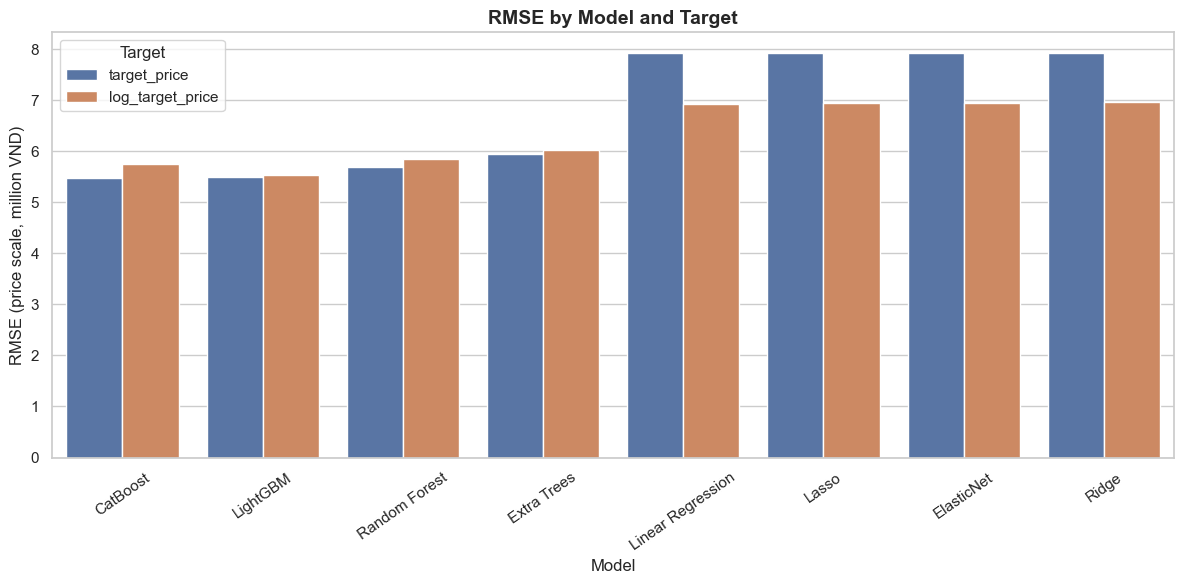

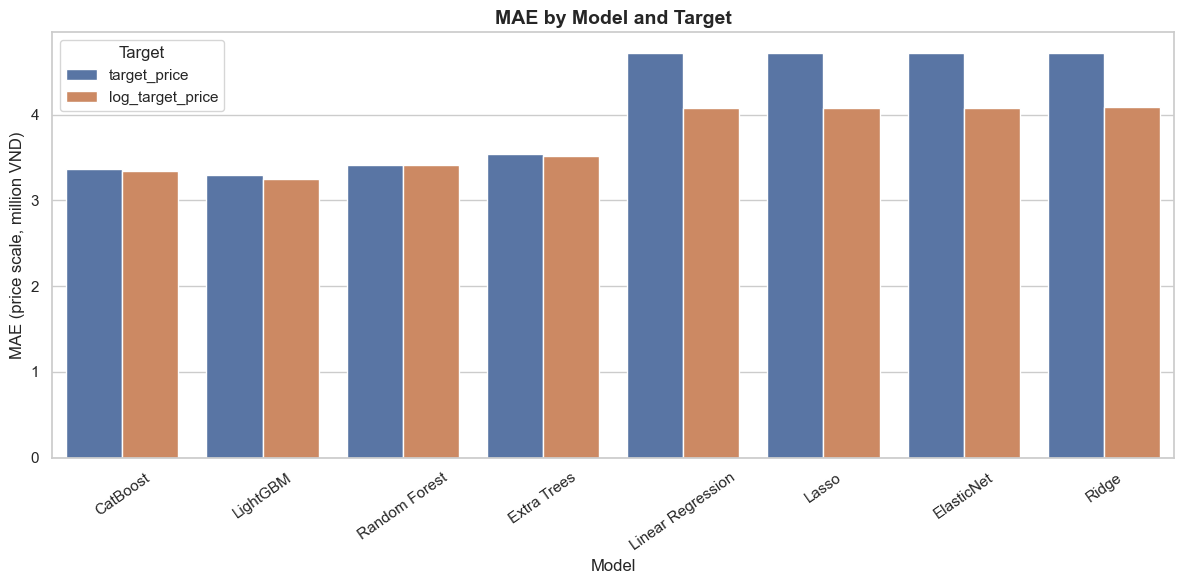

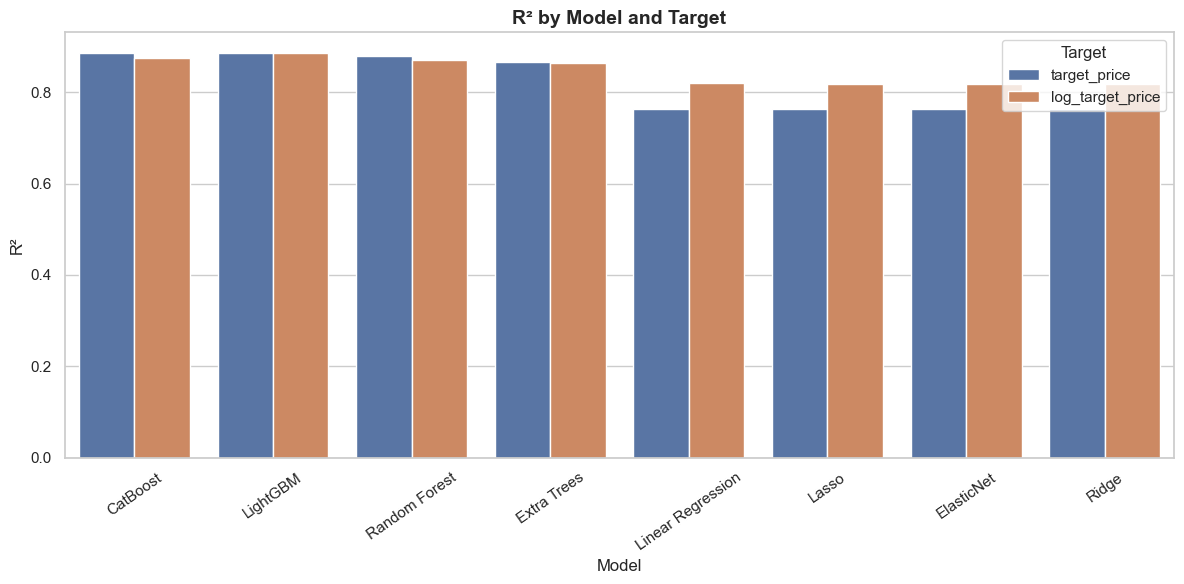

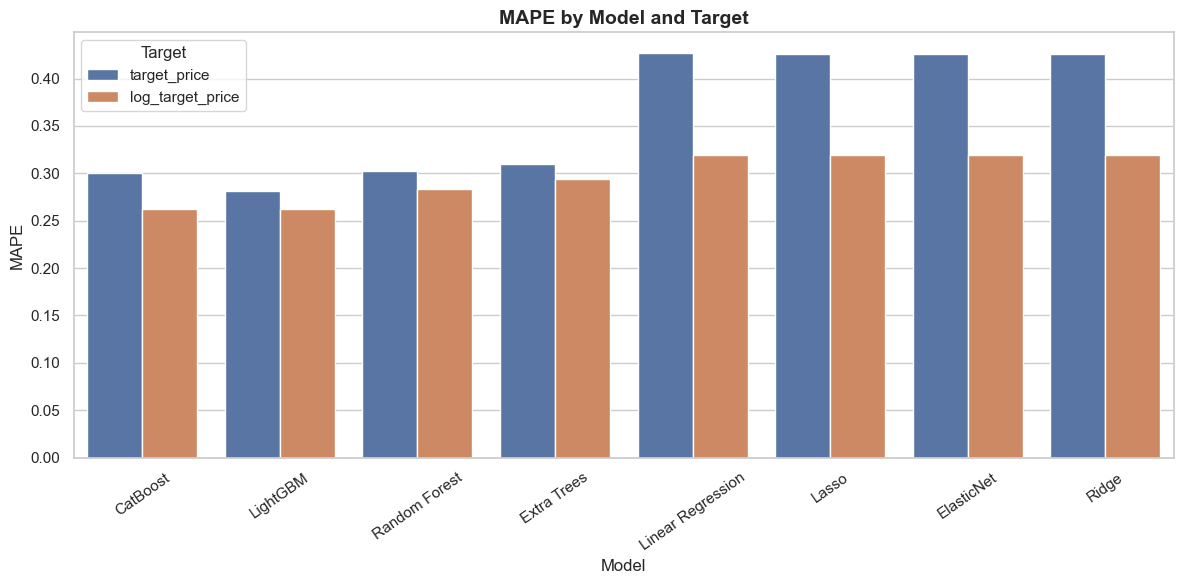

In [11]:
# Consistent model ordering by best RMSE
model_order = (
    metrics_df.groupby('model_name')['rmse'].min()
    .sort_values()
    .index.tolist()
)

target_hue_order = TARGET_ORDER
target_palette = TARGET_PALETTE


def bar_metric(metric: str, ylabel: str, title: str, ascending: bool = True) -> None:
    if metric not in metrics_df.columns:
        print(f'Metric {metric} not available, skipping.')
        return
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df = metrics_df.copy()
    plot_df['model_name'] = pd.Categorical(plot_df['model_name'], categories=model_order, ordered=True)
    plot_df = plot_df.sort_values(['model_name', 'target_used'])
    sns.barplot(
        data=plot_df,
        x='model_name',
        y=metric,
        hue='target_used',
        hue_order=target_hue_order,
        palette=target_palette,
        ax=ax,
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target')
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / f'{metric}_by_model_and_target.png', dpi=160, bbox_inches='tight')
    plt.show()


# Bar charts. Error metrics are on the original price scale, in million VND.
bar_metric('rmse', 'RMSE (price scale, million VND)', 'RMSE by Model and Target')
bar_metric('mae', 'MAE (price scale, million VND)', 'MAE by Model and Target')
bar_metric('r2', 'R²', 'R² by Model and Target', ascending=False)
if 'mape' in metrics_df.columns:
    bar_metric('mape', 'MAPE', 'MAPE by Model and Target')


### Metric Comparison by Model and Target

These charts compare each model under direct `target_price` and `log_target_price`, with all metrics computed on the original price scale.

For **RMSE**, the strongest boosting models favor direct price: CatBoost and LightGBM both have lower RMSE with `target_price`. Random Forest and Extra Trees also favor direct price, while the linear models favor log-target.

For **MAE**, `log_target_price` is broadly stronger. It wins for CatBoost, LightGBM, Extra Trees, and all linear models; Random Forest is the only paired model where direct price has a slight MAE edge.

For **R²**, the pattern mostly follows RMSE. Direct price is better for the top tree-based models, while log-target improves the linear models.

For **MAPE**, `log_target_price` wins across all models. This confirms that log transformation is most useful when relative or percentage error is the priority.

Overall, the charts show a clear trade-off: direct `target_price` is stronger for large-error metrics among the best models, while `log_target_price` is stronger for MAE/MAPE.


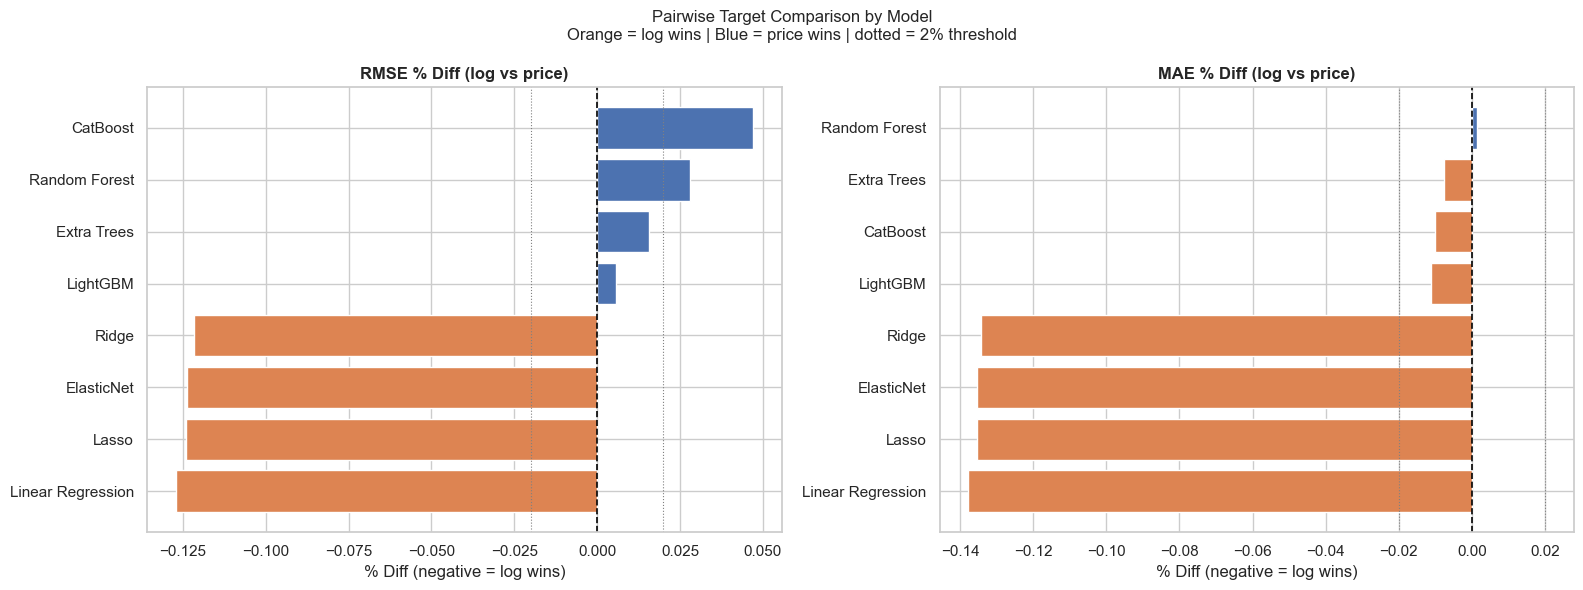

In [12]:
# ── Pairwise percentage-difference plots ──────────────────────────────────────
if not pairwise_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, metric_col, title in [
        (axes[0], 'rmse_pct_diff_log_vs_price', 'RMSE % Diff (log vs price)'),
        (axes[1], 'mae_pct_diff_log_vs_price',  'MAE % Diff (log vs price)'),
    ]:
        colors = ['#DD8452' if v < 0 else '#4C72B0'
                  for v in pairwise_df[metric_col]]
        sorted_pw = pairwise_df.sort_values(metric_col)
        ax.barh(sorted_pw['model_name'], sorted_pw[metric_col],
                color=['#DD8452' if v < 0 else '#4C72B0'
                       for v in sorted_pw[metric_col]])
        ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
        ax.axvline(-CLOSE_WIN_THRESHOLD, color='gray', linewidth=0.8, linestyle=':')
        ax.axvline( CLOSE_WIN_THRESHOLD, color='gray', linewidth=0.8, linestyle=':')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('% Diff (negative = log wins)')

    plt.suptitle('Pairwise Target Comparison by Model\n'
                 'Orange = log wins | Blue = price wins | dotted = 2% threshold',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / 'pairwise_pct_diff_by_model.png', dpi=160, bbox_inches='tight')
    plt.show()

### Pairwise Target Comparison by Model

This chart shows the percentage difference between `log_target_price` and `target_price` for each model. Negative values mean the log-target model is better; positive values mean the direct-price model is better.

For **RMSE**, direct price wins for CatBoost, LightGBM, Random Forest, and Extra Trees. The LightGBM and Extra Trees gaps are close, while CatBoost and Random Forest show clearer direct-price advantages. The linear models move in the opposite direction, with log-target producing much lower RMSE than direct price.

For **MAE**, `log_target_price` is better for nearly every model, with Random Forest as the small exception. The strongest MAE winner overall is LightGBM with `log_target_price`, but its advantage over LightGBM `target_price` is small.

The chart reinforces that target selection should depend on the primary metric. `log_target_price` is valuable for typical and percentage error, while `target_price` remains more reliable for RMSE among the strongest candidate models.


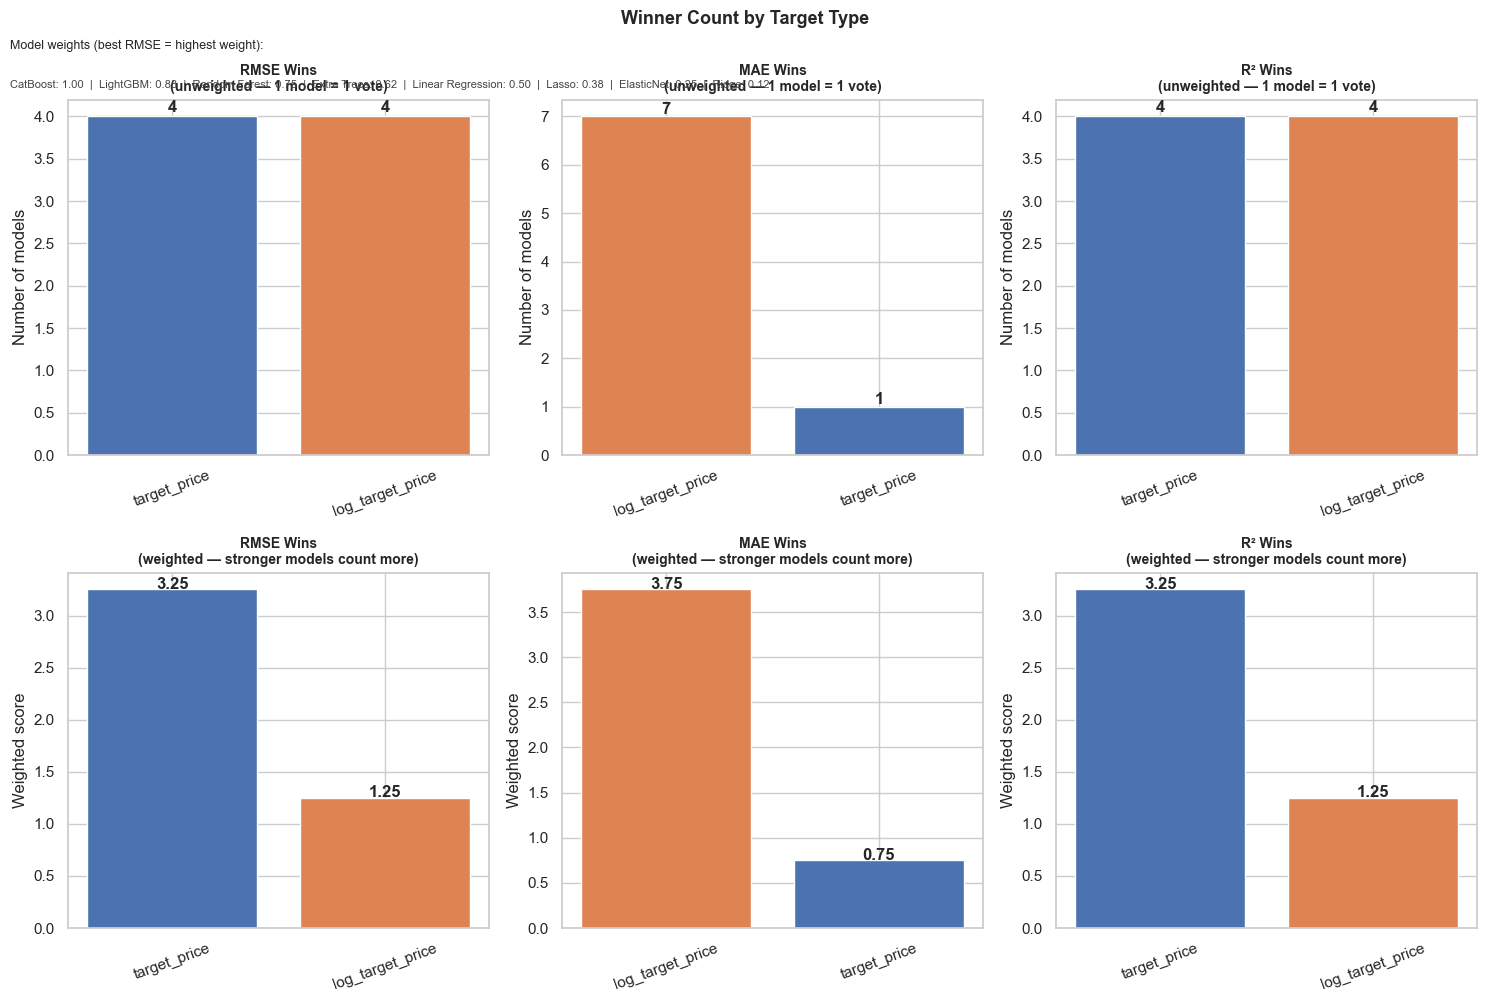

In [13]:
# ── Winner count chart (unweighted + weighted by model strength) ──────────────
if not pairwise_df.empty:
    # Compute model weights (same as cell 21)
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}

    def weighted_wins(col):
        return (
            pairwise_df[['model_name', col]]
            .assign(w=pairwise_df['model_name'].map(model_weight))
            .groupby(col)['w'].sum()
        )

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    metrics_to_plot = [
        ('rmse_winner', 'RMSE Wins'),
        ('mae_winner',  'MAE Wins'),
        ('r2_winner',   'R\u00b2 Wins'),
    ]

    def _bar_colors(index):
        return [
            '#DD8452' if idx == 'log_target_price' else
            '#4C72B0' if idx == 'target_price' else '#888888'
            for idx in index
        ]

    # Row 0: unweighted counts
    for ax, (col, title) in zip(axes[0], metrics_to_plot):
        counts = pairwise_df[col].value_counts()
        ax.bar(counts.index, counts.values,
               color=_bar_colors(counts.index), edgecolor='white')
        ax.set_title(f'{title}\n(unweighted — 1 model = 1 vote)',
                     fontweight='bold', fontsize=10)
        ax.set_ylabel('Number of models')
        ax.tick_params(axis='x', rotation=20)
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # Row 1: weighted by model strength
    for ax, (col, title) in zip(axes[1], metrics_to_plot):
        ww = weighted_wins(col).sort_values(ascending=False)
        ax.bar(ww.index, ww.values,
               color=_bar_colors(ww.index), edgecolor='white')
        ax.set_title(f'{title}\n(weighted — stronger models count more)',
                     fontweight='bold', fontsize=10)
        ax.set_ylabel('Weighted score')
        ax.tick_params(axis='x', rotation=20)
        for i, v in enumerate(ww.values):
            ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontweight='bold')

    fig.text(0.01, 0.97, 'Model weights (best RMSE = highest weight):',
             fontsize=9, va='top')
    weight_str = '  |  '.join(
        f'{m}: {w:.2f}' for m, w in
        sorted(model_weight.items(), key=lambda x: -x[1])
    )
    fig.text(0.01, 0.93, weight_str, fontsize=8, va='top', color='#444444')

    plt.suptitle('Winner Count by Target Type', fontsize=13, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / 'winner_count_by_target.png', dpi=160, bbox_inches='tight')
    plt.show()


### Winner Count by Target Type

The top row shows unweighted counts, where each model contributes one vote. The bottom row shows weighted counts, where stronger models receive more influence based on their overall performance.

**Unweighted RMSE wins** are split evenly: `log_target_price` wins 4/8 and `target_price` wins 4/8. The split is misleading unless model strength is considered, because several log-target RMSE wins come from weaker linear models.

**Weighted RMSE wins** favor direct `target_price` (3.25 vs 1.25). This reflects the fact that CatBoost, LightGBM, Random Forest, and Extra Trees favor direct price for RMSE.

**Unweighted MAE wins** strongly favor `log_target_price` (7/8), and the weighted MAE result also favors log-target (3.75 vs 0.75). This is the strongest evidence for using log-target when typical absolute error is the priority.

The weighted view supports a balanced conclusion: log-target is better for MAE/MAPE, but direct price is stronger for RMSE among the leading models.


## 10. Prediction-Level Comparison

Using the saved `test_predictions.csv`, we build a long-format error dataframe for the best price model and the best log-price model, then generate diagnostic plots.

In [14]:
if predictions_raw is not None:
    pred_df = predictions_raw.copy()
    print('Prediction columns:', pred_df.columns.tolist())
    display(pred_df.head())
else:
    print('No predictions file loaded. Skipping prediction-level analysis.')
    pred_df = None

Prediction columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,5.1244,5.0892,4.9042,5.1009,4.9049,5.0783,4.8954,5.0911,4.7560,4.3869,4.9560,5.7828,3.4152,3.6168,4.2923,3.7477
1,6004,37.4990,23.7416,20.8051,23.8598,20.7210,23.8524,20.3518,23.8449,20.4887,30.5577,29.9456,32.1394,32.5956,28.1858,31.3315,27.8331,27.6703
2,1768,27.4900,16.2240,13.5360,16.3601,13.5744,16.3640,13.4881,16.3678,13.4970,21.3259,19.5354,21.2413,19.3984,19.2228,18.4243,17.2601,16.3994
3,3360,7.8000,7.5580,6.5008,7.2300,6.4839,7.2376,6.5164,7.2294,6.4988,8.6322,8.1455,10.0000,10.0000,7.6635,7.5268,7.8962,7.2573
4,4700,12.9900,11.4057,9.5623,11.5210,9.5485,11.5308,9.7188,11.5252,9.6514,11.3804,11.4089,11.6000,11.5964,10.9634,11.0045,10.6491,10.5746


In [15]:
# ── Identify actual price column ──────────────────────────────────────────────
long_format_rows = []
errors_long_df = None

if pred_df is not None:
    # Detect the actual price column
    # IMPORTANT: y_true_price must be checked before fallback columns like sample_id
    actual_col_candidates = [
        'y_true_price',
        'actual_price',
        'target_price',
        'y_true',
        'price'
    ]

    actual_col = next((c for c in actual_col_candidates if c in pred_df.columns), None)

    if actual_col is None:
        # Safer fallback: exclude ID/index-like columns and prediction columns
        non_pred_cols = [
            c for c in pred_df.columns
            if not c.startswith('pred_')
            and c.lower() not in ['sample_id', 'id', 'index', 'row_id']
        ]

        print(f'Could not auto-detect actual column. Candidate non-pred columns: {non_pred_cols}')

        if len(non_pred_cols) == 1:
            actual_col = non_pred_cols[0]
        else:
            raise ValueError(
                "Could not safely detect actual price column. "
                f"Available columns: {list(pred_df.columns)}"
            )

    print(f'Using actual price column: {actual_col}')

    # Identify prediction columns
    pred_cols = [c for c in pred_df.columns if c.startswith('pred_')]
    print(f'Prediction columns found: {pred_cols}')

    if actual_col and pred_cols:
        y_actual = pred_df[actual_col].values

        for col in pred_cols:
            # Infer model_name and target_used from column name
            # Expected pattern: pred_<ModelName>_<target_used>
            col_suffix = col[len('pred_'):]

            if 'log_target_price' in col_suffix:
                target_u = 'log_target_price'
                model_n = col_suffix.replace('_log_target_price', '')
            elif 'target_price' in col_suffix:
                target_u = 'target_price'
                model_n = col_suffix.replace('_target_price', '')
            else:
                target_u = 'unknown'
                model_n = col_suffix

            y_pred_vals = pred_df[col].values
            residuals = y_actual - y_pred_vals
            abs_err = np.abs(residuals)
            ape = np.where(y_actual != 0, abs_err / np.abs(y_actual), np.nan)

            for i in range(len(y_actual)):
                long_format_rows.append({
                    'actual_price': y_actual[i],
                    'predicted_price': y_pred_vals[i],
                    'residual': residuals[i],
                    'absolute_error': abs_err[i],
                    'absolute_percentage_error': ape[i],
                    'model_name': model_n,
                    'target_used': target_u,
                })

        errors_long_df = pd.DataFrame(long_format_rows)

        print(f'\nLong-format error dataframe shape: {errors_long_df.shape}')
        display(errors_long_df.head())

        errors_long_df.to_csv(
            COMPARISON_DIR / 'target_comparison_prediction_errors_long.csv',
            index=False
        )

        print('Saved: target_comparison_prediction_errors_long.csv')
    else:
        print('Cannot build long-format dataframe. Missing actual column or prediction columns.')
else:
    print('Skipping long-format error table (no predictions file).')

Using actual price column: y_true_price
Prediction columns found: ['pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']

Long-format error dataframe shape: (23360, 7)


,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,model_name,target_used
0,5.5000,5.1244,0.3756,0.3756,0.0683,LinearRegression,target_price
1,37.4990,23.7416,13.7574,13.7574,0.3669,LinearRegression,target_price
2,27.4900,16.2240,11.2660,11.2660,0.4098,LinearRegression,target_price
3,7.8000,7.5580,0.2420,0.2420,0.0310,LinearRegression,target_price
4,12.9900,11.4057,1.5843,1.5843,0.1220,LinearRegression,target_price


Saved: target_comparison_prediction_errors_long.csv


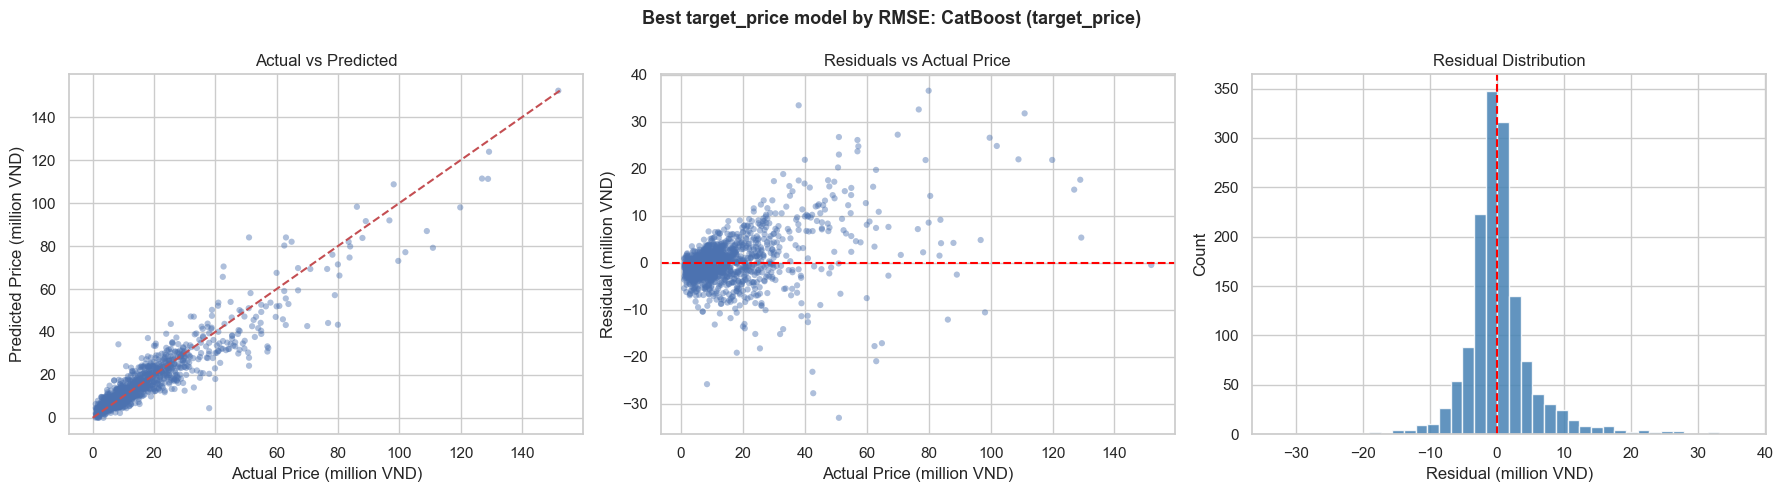

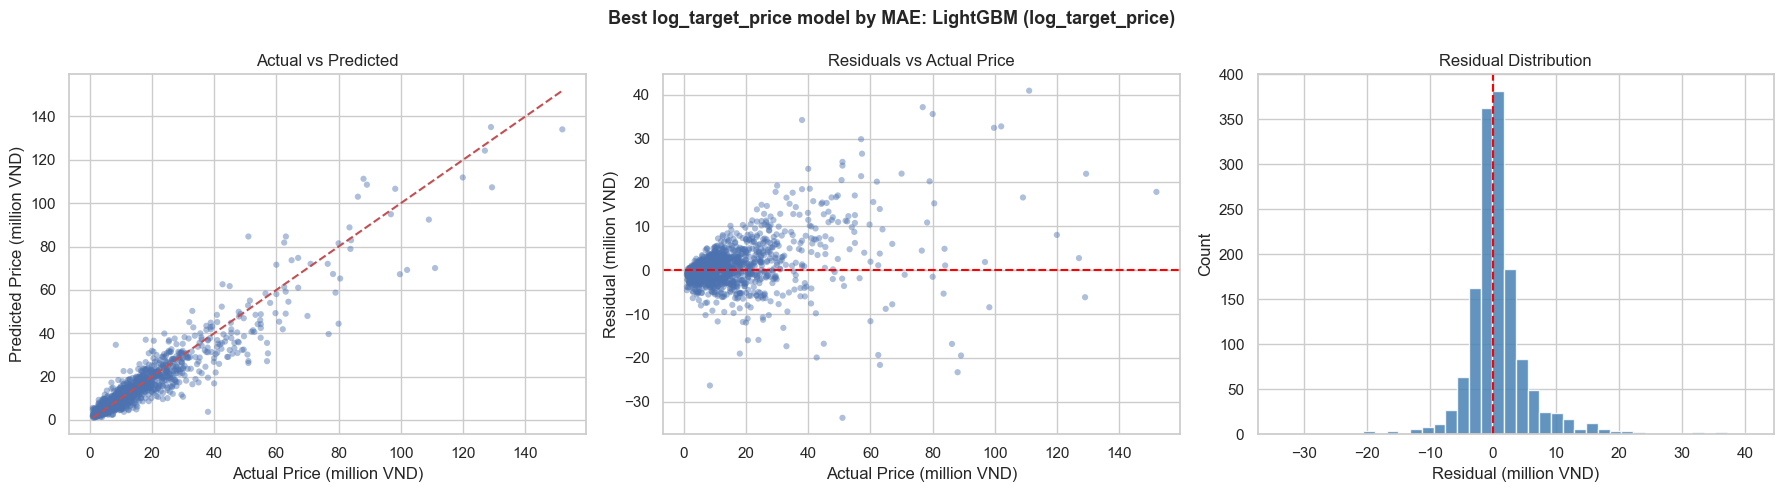

In [16]:
# Diagnostic plots for best direct-price and best log_target_price models
if errors_long_df is not None and not errors_long_df.empty:
    best_price_row = price_metrics_df.sort_values('rmse').iloc[0]
    best_log_target_row = log_target_metrics_df.sort_values('mae').iloc[0]

    def to_model_col_format(name):
        return name.replace(' ', '')

    diagnostic_models = [
        (best_price_row, 'Best target_price model by RMSE'),
        (best_log_target_row, 'Best log_target_price model by MAE'),
    ]

    for row, label in diagnostic_models:
        model_n = row['model_name']
        target_u = row['target_used']
        subset = errors_long_df[
            (errors_long_df['target_used'] == target_u) &
            (
                errors_long_df['model_name'].str.lower().str.replace(' ', '') ==
                to_model_col_format(model_n).lower()
            )
        ]

        if subset.empty:
            print(f'No predictions found for {model_n} ({target_u}). Skipping plots.')
            continue

        y_t = subset['actual_price'].values
        y_p = subset['predicted_price'].values
        res = subset['residual'].values

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'{label}: {model_n} ({target_u})', fontsize=13, fontweight='bold')

        ax = axes[0]
        ax.scatter(y_t, y_p, alpha=0.45, edgecolors='none', s=20)
        mn, mx = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
        ax.set_title('Actual vs Predicted')
        ax.set_xlabel('Actual Price (million VND)')
        ax.set_ylabel('Predicted Price (million VND)')

        ax = axes[1]
        ax.scatter(y_t, res, alpha=0.45, edgecolors='none', s=20)
        ax.axhline(0, color='red', lw=1.5, linestyle='--')
        ax.set_title('Residuals vs Actual Price')
        ax.set_xlabel('Actual Price (million VND)')
        ax.set_ylabel('Residual (million VND)')

        ax = axes[2]
        ax.hist(res, bins=40, edgecolor='white', color='steelblue', alpha=0.85)
        ax.axvline(0, color='red', lw=1.5, linestyle='--')
        ax.set_title('Residual Distribution')
        ax.set_xlabel('Residual (million VND)')
        ax.set_ylabel('Count')

        plt.tight_layout()
        safe_name = f"{to_model_col_format(model_n)}_{target_u}"
        plt.savefig(COMPARISON_DIR / f'diagnostic_{safe_name}.png', dpi=160, bbox_inches='tight')
        plt.show()
else:
    print('Skipping diagnostic plots (no long-format error dataframe).')


### Best Model Diagnostic Comparison

These diagnostic plots compare the best direct-price model with the best log-target model on the original price scale. With the updated metrics, the strongest direct-price model is **CatBoost with `target_price`**, while the strongest log-target model by MAE is **LightGBM with `log_target_price`**.

Both models should show good alignment between actual and predicted prices for the low-to-mid price range. Errors become wider for expensive laptops, which is expected because premium devices have larger absolute price variation.

The residual plots should be interpreted together with the metric table: the direct-price winner controls large errors better, while the log-target winner reduces typical and percentage-based error. Visual differences may be modest, so the final decision should rely on the metric rule rather than the plots alone.

Overall, the diagnostics support keeping both direct-price and log-target boosting models as candidates, with the final balanced choice favoring the model that preserves low MAE while improving RMSE.


## 11. Segment-Level Error Analysis

We split the test set into four price segments using quantile-based bins:
- **Low**: 0–25th percentile
- **Mid**: 25th–50th percentile
- **High**: 50th–75th percentile
- **Premium**: 75th–100th percentile

Segment-level analysis reveals whether log-transform helps more in lower price ranges and whether it degrades accuracy for premium laptops.

In [17]:
segment_df = None

if errors_long_df is not None and not errors_long_df.empty:
    # Create segments based on actual_price quantiles
    q25, q50, q75 = np.quantile(errors_long_df['actual_price'].unique(), [0.25, 0.5, 0.75])
    print(f'Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}')

    def assign_segment(price):
        if price <= q25:
            return 'Low'
        elif price <= q50:
            return 'Mid'
        elif price <= q75:
            return 'High'
        else:
            return 'Premium'

    errors_long_df['price_segment'] = errors_long_df['actual_price'].apply(assign_segment)
    errors_long_df['price_segment'] = pd.Categorical(
        errors_long_df['price_segment'],
        categories=['Low', 'Mid', 'High', 'Premium'],
        ordered=True
    )

    # Segment-level metrics
    seg_records = []
    for (model_n, target_u, segment), grp in errors_long_df.groupby(
        ['model_name', 'target_used', 'price_segment'], observed=True
    ):
        yt = grp['actual_price'].values
        yp = grp['predicted_price'].values
        res = grp['residual'].values

        seg_records.append({
            'model_name'           : model_n,
            'target_used'          : target_u,
            'price_segment'        : segment,
            'count'                : len(yt),
            'mae'                  : mean_absolute_error(yt, yp),
            'rmse'                 : root_mean_squared_error(yt, yp),
            'mape'                 : mean_absolute_percentage_error(yt, yp),
            'median_absolute_error': median_absolute_error(yt, yp),
            'mean_residual'        : res.mean(),
        })

    segment_df = pd.DataFrame(seg_records)
    display(segment_df.sort_values(['model_name', 'target_used', 'price_segment']).head(30))

    segment_df.to_csv(
        COMPARISON_DIR / 'target_comparison_error_by_price_segment.csv', index=False
    )
    print('Saved: target_comparison_error_by_price_segment.csv')
else:
    print('Skipping segment analysis (no long-format error data).')

Price quantiles: Q25=8  Q50=17  Q75=29


,model_name,target_used,price_segment,count,mae,rmse,mape,median_absolute_error,mean_residual
2,CatBoost,log_target_price,High,252,4.4217,5.7131,0.2003,3.3871,1.3473
0,CatBoost,log_target_price,Low,597,1.4258,2.0734,0.3439,1.0407,-0.4992
1,CatBoost,log_target_price,Mid,437,2.3643,3.0275,0.2024,1.8680,0.4108
3,CatBoost,log_target_price,Premium,174,10.7662,13.8378,0.2206,9.2587,7.6964
6,CatBoost,target_price,High,252,4.2915,5.4999,0.1952,3.6327,0.4169
4,CatBoost,target_price,Low,597,1.7387,2.5270,0.4362,1.2715,-0.9358
5,CatBoost,target_price,Mid,437,2.4806,3.2600,0.2130,1.8808,-0.1616
7,CatBoost,target_price,Premium,174,9.8734,12.6418,0.2041,7.7098,6.0205
10,ElasticNet,log_target_price,High,252,5.9957,7.6119,0.2722,4.9460,1.4969
8,ElasticNet,log_target_price,Low,597,1.5875,2.1180,0.4112,1.2219,-0.7675


Saved: target_comparison_error_by_price_segment.csv


### Price Segment Error Analysis

The price quantiles divide the test set into four segments:

- Low: lower-price laptops
- Mid: lower-middle price laptops
- High: upper-middle price laptops
- Premium: the most expensive laptops

For CatBoost, `log_target_price` improves the Low and Mid segments, while direct `target_price` is better in the High and Premium segments. This is more nuanced than the previous interpretation: log-target is not uniformly better across the first three segments.

The Premium segment remains the hardest segment in absolute-error terms. CatBoost `target_price` has lower MAE, RMSE, and MAPE than CatBoost `log_target_price` for Premium laptops, which supports keeping a direct-price candidate when high-end accuracy or large-error control matters.

Residual bias still shows compression toward the middle of the price distribution: cheaper laptops tend to be overpredicted and premium laptops tend to be underpredicted. This is a common pattern in price models and should be monitored again after tuning.


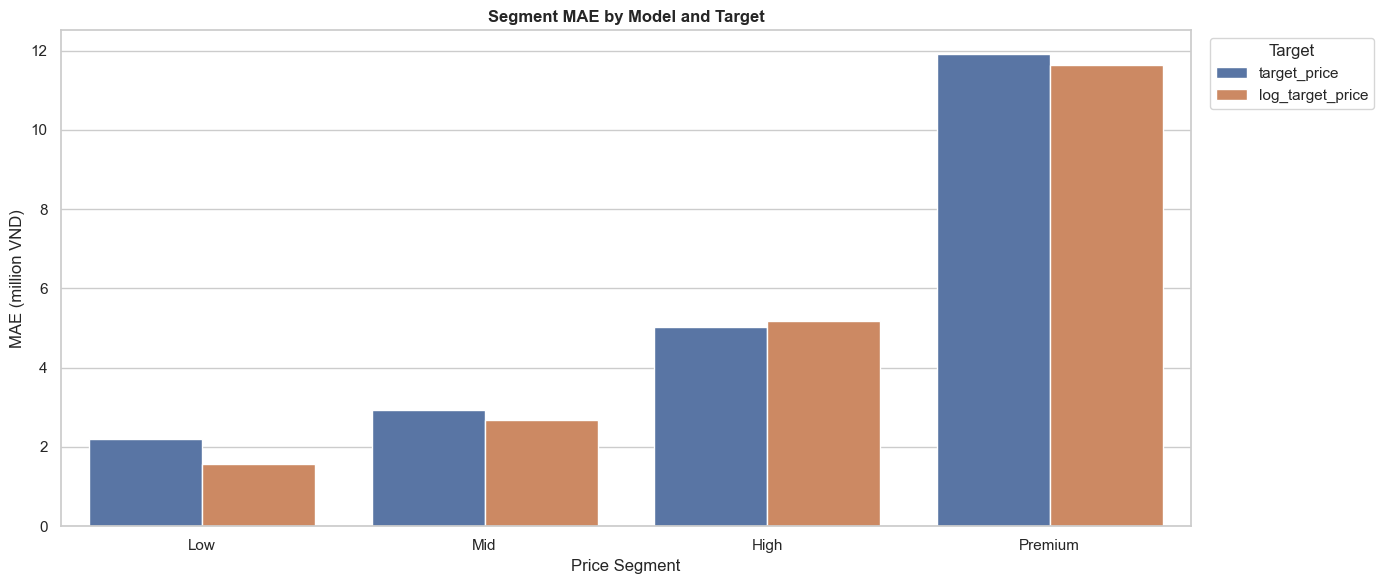

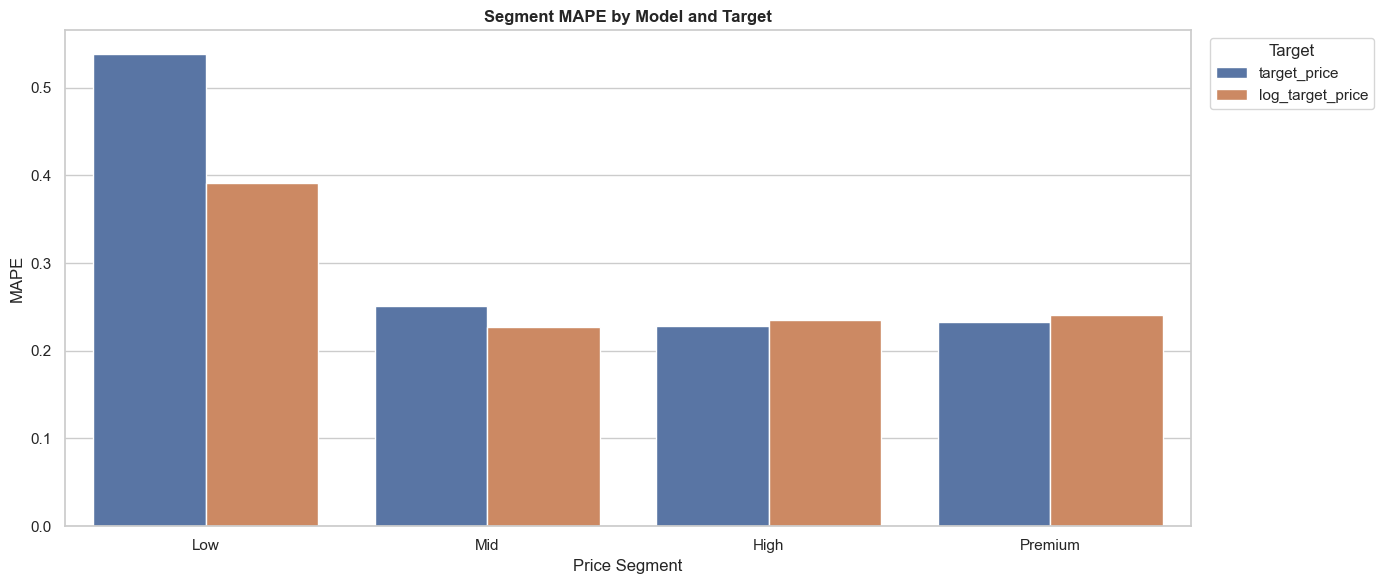

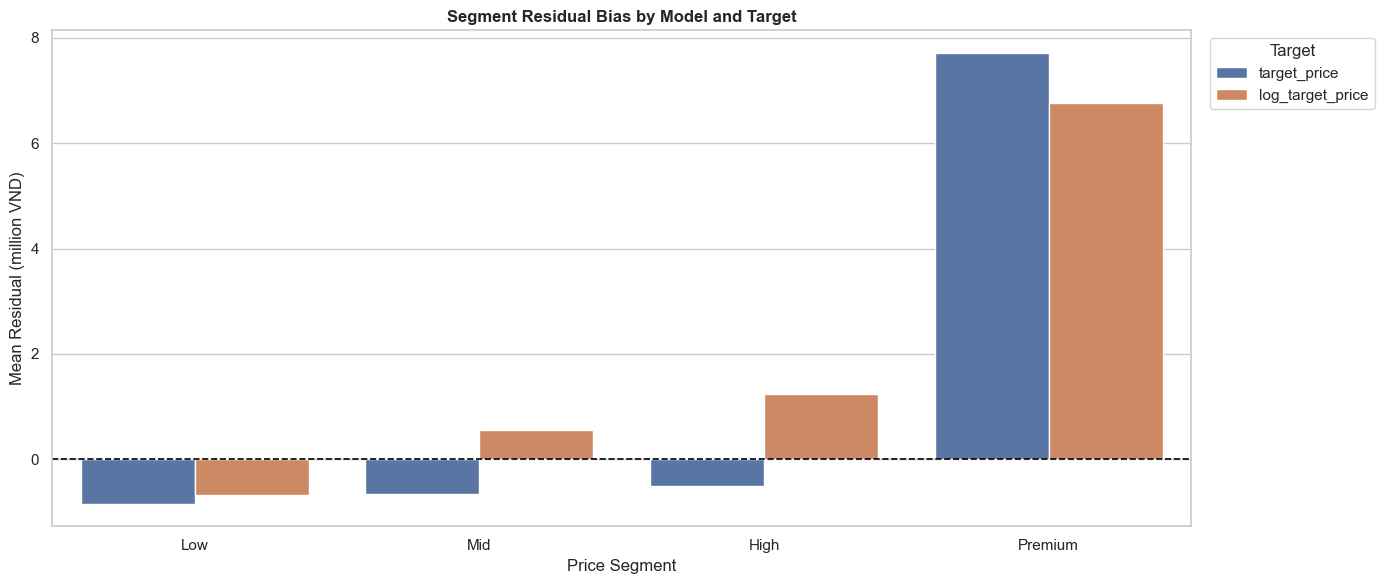

In [18]:
# Segment-level plots
if segment_df is not None and not segment_df.empty:
    segment_df['target_used'] = pd.Categorical(
        segment_df['target_used'],
        categories=TARGET_ORDER,
        ordered=True,
    )

    for metric, ylabel, title in [
        ('mae', 'MAE (million VND)', 'Segment MAE by Model and Target'),
        ('mape', 'MAPE', 'Segment MAPE by Model and Target'),
        ('mean_residual', 'Mean Residual (million VND)', 'Segment Residual Bias by Model and Target'),
    ]:
        fig, ax = plt.subplots(figsize=(14, 6))
        plot_df = segment_df.sort_values(['model_name', 'target_used'])
        sns.barplot(
            data=plot_df,
            x='price_segment',
            y=metric,
            hue='target_used',
            hue_order=target_hue_order,
            palette=target_palette,
            ax=ax,
            errorbar=None,
        )
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Price Segment')
        ax.set_ylabel(ylabel)
        if metric == 'mean_residual':
            ax.axhline(0, color='black', lw=1.2, linestyle='--')
        ax.tick_params(axis='x', rotation=0)
        ax.legend(title='Target', bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(COMPARISON_DIR / f'segment_{metric}_by_model_target.png',
                    dpi=160, bbox_inches='tight')
        plt.show()
else:
    print('Skipping segment plots.')


### Segment-Level Error Analysis by Model and Target

These charts evaluate model performance across price segments instead of relying only on overall metrics.

Segment MAE generally rises with price, so Premium laptops are the hardest to predict in absolute terms. The stronger boosting and tree ensemble models remain clearly better than the linear models across most segments.

For CatBoost, the updated segment table shows a mixed target effect: log-target is better in Low and Mid, while direct price is better in High and Premium. This supports the broader conclusion that log transformation helps relative or typical errors but can lose ground on more expensive laptops.

The residual-bias chart still indicates prediction compression: lower-price laptops are often overpredicted, while premium laptops are underpredicted. The MAPE chart favors log-target more often because log transformation directly encourages relative-error behavior.

Overall, segment analysis supports keeping both target strategies for the strongest boosting models, especially if the deployment objective must balance common-price accuracy against Premium-segment errors.


## 12. Best Model Selection

We identify top performers by RMSE, MAE, and a balanced rule. If the leading MAE results are within 2%, the model with lower RMSE and then higher R² is selected as the balanced candidate.


In [19]:
best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row = metrics_df.loc[metrics_df['mae'].idxmin()]

# Best balanced: MAE-primary, RMSE tiebreak. This keeps the user-facing
# average error objective, but avoids choosing a model with materially worse
# large-error behavior when MAE is effectively tied.
sorted_by_mae = metrics_df.sort_values('mae').reset_index(drop=True)
top1_mae = sorted_by_mae.iloc[0]['mae']
close_mae_candidates = sorted_by_mae[
    (sorted_by_mae['mae'] - top1_mae) / top1_mae <= CLOSE_WIN_THRESHOLD
].copy()

best_balanced_row = close_mae_candidates.sort_values(['rmse', 'r2'], ascending=[True, False]).iloc[0]
tiebreak_note = (
    f'{len(close_mae_candidates)} MAE-leading results are within '
    f'{CLOSE_WIN_THRESHOLD * 100:.0f}%; RMSE then R² used as tiebreakers.'
)

print('=== Best Model by RMSE ===')
print(best_rmse_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print()
print('=== Best Model by MAE ===')
print(best_mae_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print()
print('=== Best Balanced Model (primary: MAE, tiebreak: RMSE/R²) ===')
print(best_balanced_row[['model_name', 'target_used', 'rmse', 'mae', 'r2']].to_string())
print(f'Note: {tiebreak_note}')


=== Best Model by RMSE ===
model_name         CatBoost
target_used    target_price
rmse                 5.4827
mae                  3.3709
r2                   0.8870

=== Best Model by MAE ===
model_name             LightGBM
target_used    log_target_price
rmse                     5.5300
mae                      3.2535
r2                       0.8850

=== Best Balanced Model (primary: MAE, tiebreak: RMSE/R²) ===
model_name         LightGBM
target_used    target_price
rmse                 5.4981
mae                  3.2904
r2                   0.8864
Note: 2 MAE-leading results are within 2%; RMSE then R² used as tiebreakers.


### Best Model Selection

This section selects the strongest model using three criteria: lowest RMSE, lowest MAE, and a balanced rule that uses **MAE as the primary metric**, with RMSE as a tiebreaker when the top MAE results are within 2%.

**Best model by RMSE: CatBoost with `target_price`**
- RMSE = 5.4827, MAE = 3.3709, R² = 0.8870

**Best model by MAE: LightGBM with `log_target_price`**
- MAE = 3.2535, RMSE = 5.5300, R² = 0.8850

**Best balanced model: LightGBM with `target_price`**
- MAE = 3.2904, RMSE = 5.4981, R² = 0.8864
- The best MAE results are within the 2% close-result threshold, so RMSE is used as the tiebreaker.

This makes LightGBM `target_price` the most balanced choice under the current rule, while CatBoost `target_price` remains the pure RMSE winner and LightGBM `log_target_price` remains the pure MAE winner.


## 13. Markdown Interpretation and Conclusion

In [20]:
# ── Compute summary statistics for interpretation ─────────────────────────────
avg_rmse_by_target = metrics_df.groupby('target_used')['rmse'].mean()
avg_mae_by_target  = metrics_df.groupby('target_used')['mae'].mean()

log_better_rmse = False
log_better_mae  = False

if 'log_target_price' in avg_rmse_by_target.index and 'target_price' in avg_rmse_by_target.index:
    log_better_rmse = avg_rmse_by_target['log_target_price'] < avg_rmse_by_target['target_price']
    log_better_mae  = avg_mae_by_target['log_target_price']  < avg_mae_by_target['target_price']

n_models_log_wins_rmse = 0
n_models_log_wins_mae  = 0
log_weighted_mae = log_weighted_rmse = total_weight = 0

if not pairwise_df.empty:
    n_models_log_wins_rmse = (pairwise_df['rmse_winner'] == 'log_target_price').sum()
    n_models_log_wins_mae  = (pairwise_df['mae_winner']  == 'log_target_price').sum()
    total_paired = len(pairwise_df)

    # Weighted wins
    model_best_rmse = metrics_df.groupby('model_name')['rmse'].min().sort_values()
    n_w = len(model_best_rmse)
    model_weight = {m: (n_w - rank) / n_w
                    for rank, m in enumerate(model_best_rmse.index)}
    total_weight = sum(model_weight.values())

    log_weighted_mae  = sum(model_weight[r['model_name']] for _, r in pairwise_df.iterrows()
                            if r['mae_winner']  == 'log_target_price')
    log_weighted_rmse = sum(model_weight[r['model_name']] for _, r in pairwise_df.iterrows()
                            if r['rmse_winner'] == 'log_target_price')
else:
    total_paired = 0

# ── Print interpretation ──────────────────────────────────────────────────────
print('=' * 70)
print('INTERPRETATION SUMMARY')
print('=' * 70)
print()
print(f'Best individual model by RMSE    : {best_rmse_row["model_name"]} '
      f'({best_rmse_row["target_used"]})')
print(f'  RMSE={best_rmse_row["rmse"]:,.2f}  '
      f'MAE={best_rmse_row["mae"]:,.2f}  '
      f'R\u00b2={best_rmse_row["r2"]:,.4f}')
print()
print(f'Best individual model by MAE     : {best_mae_row["model_name"]} '
      f'({best_mae_row["target_used"]})')
print(f'  MAE={best_mae_row["mae"]:,.2f}  '
      f'RMSE={best_mae_row["rmse"]:,.2f}  '
      f'R\u00b2={best_mae_row["r2"]:,.4f}')
print()
print(f'Best balanced model (MAE-primary): {best_balanced_row["model_name"]} '
      f'({best_balanced_row["target_used"]})')
print(f'  {tiebreak_note}')
print()

if total_paired > 0:
    print(f'Log-target wins RMSE: {n_models_log_wins_rmse}/{total_paired} models  '
          f'(weighted: {log_weighted_rmse:.2f}/{total_weight:.2f})')
    print(f'Log-target wins MAE : {n_models_log_wins_mae}/{total_paired} models  '
          f'(weighted: {log_weighted_mae:.2f}/{total_weight:.2f})')
    print()
    print('Weighted scores give higher influence to stronger (lower-RMSE) models.')
    print('A weighted score > 0.5 x total_weight means log-target wins among the')
    print('better-performing models, regardless of raw model count.')
    print()

if log_better_rmse and log_better_mae:
    print('OVERALL: log_target_price yields lower average RMSE and MAE across all models.')
elif not log_better_rmse and not log_better_mae:
    print('OVERALL: target_price (direct) yields lower average RMSE and MAE across all models.')
else:
    print('OVERALL: mixed — log_target_price improves MAE but not average RMSE (or vice versa).')

print()
if not pairwise_df.empty:
    log_benefit_models = pairwise_df[
        (pairwise_df['rmse_winner'] == 'log_target_price') |
        (pairwise_df['mae_winner']  == 'log_target_price')
    ]['model_name'].tolist()
    log_harm_models = pairwise_df[
        (pairwise_df['rmse_winner'] == 'target_price') &
        (pairwise_df['mae_winner']  == 'target_price')
    ]['model_name'].tolist()

    print(f'Models that benefit from log_target_price : {log_benefit_models}')
    print(f'Models that do NOT benefit (both metrics) : {log_harm_models}')


INTERPRETATION SUMMARY

Best individual model by RMSE    : CatBoost (target_price)
  RMSE=5.48  MAE=3.37  R²=0.8870

Best individual model by MAE     : LightGBM (log_target_price)
  MAE=3.25  RMSE=5.53  R²=0.8850

Best balanced model (MAE-primary): LightGBM (target_price)
  2 MAE-leading results are within 2%; RMSE then R² used as tiebreakers.

Log-target wins RMSE: 4/8 models  (weighted: 1.25/4.50)
Log-target wins MAE : 7/8 models  (weighted: 3.75/4.50)

Weighted scores give higher influence to stronger (lower-RMSE) models.
A weighted score > 0.5 x total_weight means log-target wins among the
better-performing models, regardless of raw model count.

OVERALL: log_target_price yields lower average RMSE and MAE across all models.

Models that benefit from log_target_price : ['CatBoost', 'ElasticNet', 'Extra Trees', 'Lasso', 'LightGBM', 'Linear Regression', 'Ridge']
Models that do NOT benefit (both metrics) : ['Random Forest']


### Conclusion

With **MAE as the primary metric** and RMSE used as a tiebreaker for close MAE results, the current level-encoded notebook selects:

**Best balanced model: LightGBM with `target_price`**. It has MAE = 3.2904, RMSE = 5.4981, and R² = 0.8864. Its MAE is within 2% of the best MAE result, while its RMSE is better than the log-target alternatives.

**Best RMSE model:** CatBoost with `target_price` (RMSE = 5.4827, R² = 0.8870). This is the strongest option if large-error control is the main objective.

**Best MAE model:** LightGBM with `log_target_price` (MAE = 3.2535, MAPE = 0.2627). This is the strongest option if typical prediction error is prioritized without applying the RMSE tiebreaker.

The target comparison is mixed: `log_target_price` wins MAE for 7/8 models and MAPE for all models, but direct `target_price` wins the weighted RMSE comparison because the strongest tree-based models favor direct price on RMSE.

Final recommendation for this notebook: use **LightGBM with `target_price`** as the balanced pre-tuning candidate, while retaining **CatBoost with `target_price`** and **LightGBM with `log_target_price`** as important alternatives for tuning.


## 15. Model Family Classification

We group models into families and broader family groups to understand which class of algorithm performs best. This classification will guide the fine-tuning notebook by focusing effort on the most promising model families.

In [21]:
# ── Model family mapping ─────────────────────────────────────────────────────
FAMILY_MAP = {
    # Linear models
    'linear regression' : ('Linear Regression', 'Linear'),
    'ridge'             : ('Ridge',             'Linear'),
    'lasso'             : ('Lasso',             'Linear'),
    'elasticnet'        : ('ElasticNet',        'Linear'),
    'elastic net'       : ('ElasticNet',        'Linear'),
    # Bagging / ensemble tree models
    'random forest'     : ('Random Forest',     'Tree Ensemble'),
    'randomforest'      : ('Random Forest',     'Tree Ensemble'),
    'extra trees'       : ('Extra Trees',       'Tree Ensemble'),
    'extratrees'        : ('Extra Trees',       'Tree Ensemble'),
    'extra tree'        : ('Extra Trees',       'Tree Ensemble'),
    # Boosting models
    'catboost'          : ('CatBoost',          'Boosting'),
    'lightgbm'          : ('LightGBM',          'Boosting'),
    'light gbm'         : ('LightGBM',          'Boosting'),
    'xgboost'           : ('XGBoost',           'Boosting'),
}

def get_model_family(name: str):
    """Return (model_family, model_family_group) for a model name string."""
    key = name.strip().lower()
    # Exact match first
    if key in FAMILY_MAP:
        return FAMILY_MAP[key]
    # Partial / substring match
    for k, v in FAMILY_MAP.items():
        if k in key:
            return v
    return ('Unknown', 'Unknown')

# ── Add columns to metrics_df ─────────────────────────────────────────────────
metrics_df[['model_family', 'model_family_group']] = (
    metrics_df['model_name']
    .apply(lambda n: pd.Series(get_model_family(n)))
)

# ── Display family metrics table ──────────────────────────────────────────────
display_cols = ['model_name', 'model_family', 'model_family_group', 'target_used',
                'rmse', 'mae', 'r2']
if 'mape' in metrics_df.columns:
    display_cols.append('mape')

family_metrics_df = (
    metrics_df[display_cols]
    .sort_values(['model_family_group', 'model_family', 'rmse'])
    .reset_index(drop=True)
)

print('=== Model Family Metrics ===')
display(family_metrics_df)

family_metrics_df.to_csv(COMPARISON_DIR / 'model_family_metrics.csv', index=False)
print('Saved: model_family_metrics.csv')

# ── Verify coverage ───────────────────────────────────────────────────────────
unknown = metrics_df[metrics_df['model_family'] == 'Unknown']['model_name'].unique()
if len(unknown):
    print(f'WARNING: Unmapped model names: {unknown.tolist()}')
else:
    print('All model names mapped to a family.')


=== Model Family Metrics ===


,model_name,model_family,model_family_group,target_used,rmse,mae,r2,mape
0,CatBoost,CatBoost,Boosting,target_price,5.4827,3.3709,0.8870,0.3001
1,CatBoost,CatBoost,Boosting,log_target_price,5.7407,3.3370,0.8761,0.2621
2,LightGBM,LightGBM,Boosting,target_price,5.4981,3.2904,0.8864,0.2817
3,LightGBM,LightGBM,Boosting,log_target_price,5.5300,3.2535,0.8850,0.2627
4,ElasticNet,ElasticNet,Linear,log_target_price,6.9437,4.0807,0.8188,0.3194
5,ElasticNet,ElasticNet,Linear,target_price,7.9246,4.7187,0.7639,0.4258
6,Lasso,Lasso,Linear,log_target_price,6.9425,4.0807,0.8188,0.3196
7,Lasso,Lasso,Linear,target_price,7.9250,4.7197,0.7639,0.4259
8,Linear Regression,Linear Regression,Linear,log_target_price,6.9260,4.0736,0.8197,0.3191
9,Linear Regression,Linear Regression,Linear,target_price,7.9334,4.7241,0.7634,0.4274


Saved: model_family_metrics.csv
All model names mapped to a family.


### Model Family Classification Interpretation

This table groups models into **Boosting**, **Tree Ensemble**, and **Linear** families.

The **Boosting** models remain the strongest family overall. CatBoost and LightGBM occupy the top ranks, with direct-price variants leading RMSE/R² and log-target variants improving MAE/MAPE.

The **Tree Ensemble** models, Random Forest and Extra Trees, are competitive but generally trail the boosting models. They remain useful secondary baselines and optional tuning candidates.

The **Linear** models improve when trained on `log_target_price` in this level-encoded dataset, but they still sit below the tree-based models in the overall ranking. They should remain benchmarks rather than final candidates.

Overall, the family view supports focusing tuning on **Boosting models first**, then keeping selected tree ensembles as secondary checks.


## 16. Model Family Performance Summary

We aggregate target_price-scale metrics by model family group and target type. This identifies which model families are worth tuning, while keeping log-scale diagnostics separate from price-scale selection.


In [22]:
# ── Group by family group and target ─────────────────────────────────────────
agg_exprs = {
    'rmse': ['mean', 'median'],
    'mae' : ['mean', 'median'],
    'r2'  : ['mean'],
}
if 'mape' in metrics_df.columns:
    agg_exprs['mape'] = ['mean']

family_perf_df = (
    metrics_df
    .groupby(['model_family_group', 'target_used'])
    .agg(agg_exprs)
)
family_perf_df.columns = ['_'.join(c) for c in family_perf_df.columns]
family_perf_df['n_models'] = (
    metrics_df
    .groupby(['model_family_group', 'target_used'])
    .size()
)
family_perf_df = (
    family_perf_df
    .reset_index()
    .sort_values('rmse_mean')
    .reset_index(drop=True)
)

print('=== Model Family Performance Summary (sorted by mean RMSE) ===')
display(family_perf_df)

family_perf_df.to_csv(COMPARISON_DIR / 'model_family_performance_summary.csv', index=False)
print('Saved: model_family_performance_summary.csv')


=== Model Family Performance Summary (sorted by mean RMSE) ===


,model_family_group,target_used,rmse_mean,rmse_median,mae_mean,mae_median,r2_mean,mape_mean,n_models
0,Boosting,target_price,5.4904,5.4904,3.3306,3.3306,0.8867,0.2909,2
1,Boosting,log_target_price,5.6353,5.6353,3.2952,3.2952,0.8806,0.2624,2
2,Tree Ensemble,target_price,5.8128,5.8128,3.4763,3.4763,0.8729,0.3058,2
3,Tree Ensemble,log_target_price,5.9387,5.9387,3.4650,3.4650,0.8674,0.2883,2
4,Linear,log_target_price,6.9431,6.9431,4.0804,4.0807,0.8188,0.3193,4
5,Linear,target_price,7.9270,7.9249,4.7207,4.7199,0.7638,0.4263,4


Saved: model_family_performance_summary.csv


### Model Family Performance Summary Interpretation

The model-family summary shows that **Boosting with `target_price`** has the lowest average RMSE and highest average R². **Boosting with `log_target_price`** has slightly lower average MAE and clearly lower MAPE.

Tree Ensemble models rank second. Their direct-price variants have better RMSE/R², while log-target variants have better MAE/MAPE.

Linear models are weakest overall, although the level-encoded linear models benefit strongly from log-target compared with direct price.

The family-level conclusion is consistent with the model-level result: boosting is the main family to tune, and target strategy should be selected by metric priority rather than assumed universally.


## 17. Model Family Comparison Visualizations

The following plots compare mean RMSE, MAE, MAPE, and R² by model family group and target type, providing a quick visual overview of relative algorithm performance.

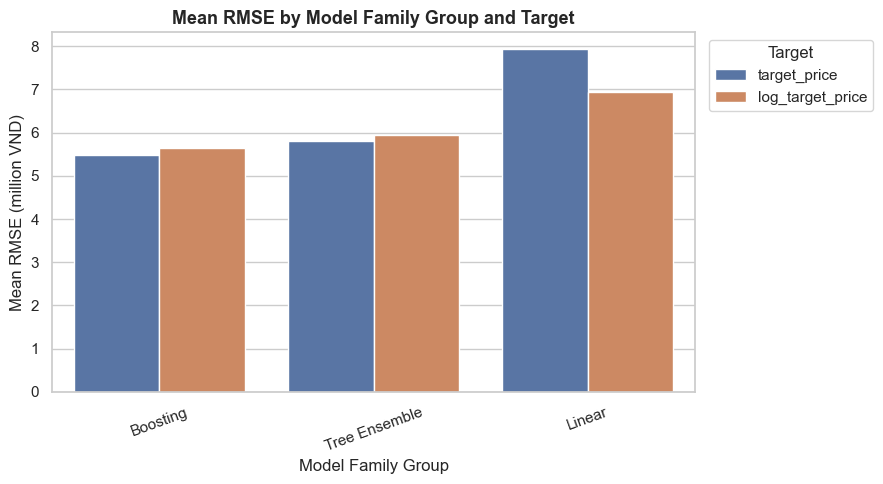

Saved: model_family_rmse_by_target.png


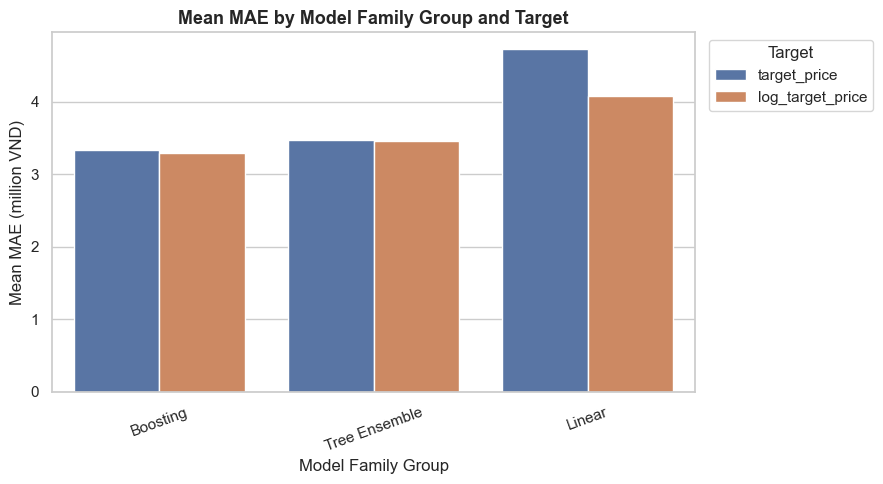

Saved: model_family_mae_by_target.png


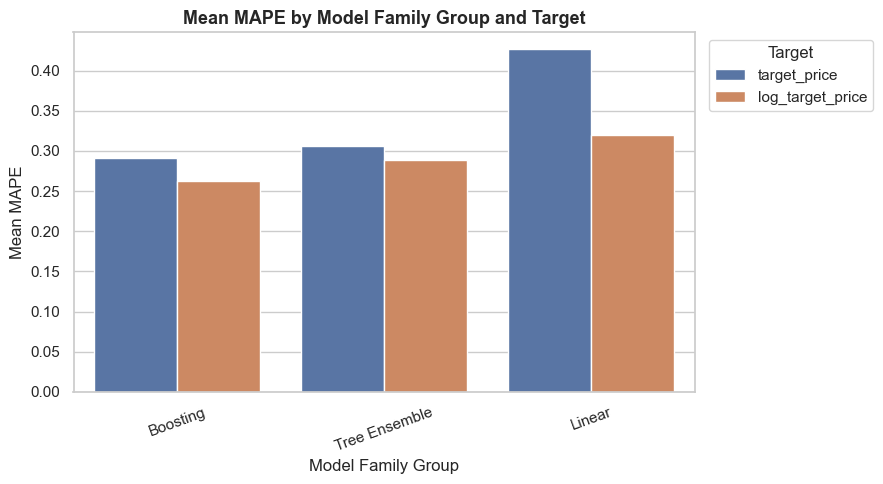

Saved: model_family_mape_by_target.png


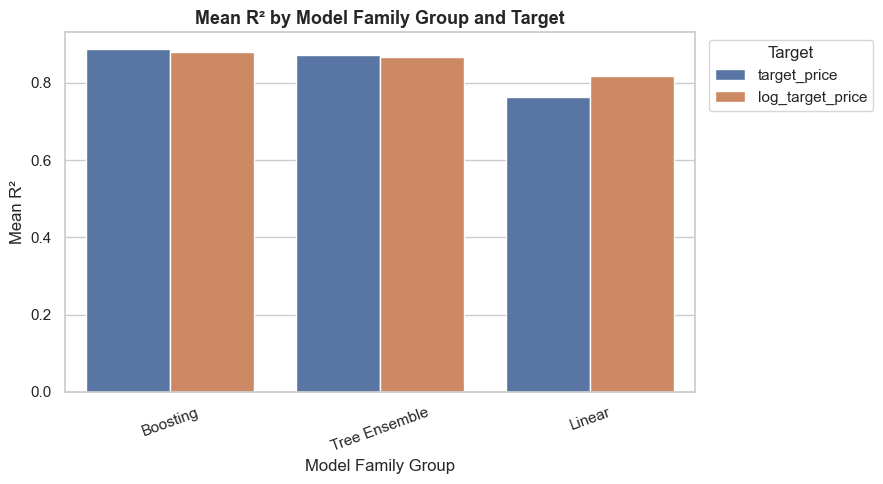

Saved: model_family_r2_by_target.png


In [23]:
# Prepare plot data
_plot_df = family_perf_df.copy()
_plot_df['target_used'] = pd.Categorical(
    _plot_df['target_used'],
    categories=TARGET_ORDER,
    ordered=True,
)

_family_order = ['Boosting', 'Tree Ensemble', 'Linear']
_existing_groups = [g for g in _family_order if g in _plot_df['model_family_group'].unique()]


def _family_bar_plot(metric_col, ylabel, title, filename, higher_is_better=False):
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = _plot_df.sort_values(['model_family_group', 'target_used'])
    sns.barplot(
        data=plot_df,
        x='model_family_group',
        y=metric_col,
        hue='target_used',
        order=_existing_groups,
        hue_order=target_hue_order,
        palette=target_palette,
        ax=ax,
        errorbar=None,
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Model Family Group')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Target', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / filename, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


_family_bar_plot('rmse_mean', 'Mean RMSE (million VND)', 'Mean RMSE by Model Family Group and Target',
                 'model_family_rmse_by_target.png')
_family_bar_plot('mae_mean', 'Mean MAE (million VND)', 'Mean MAE by Model Family Group and Target',
                 'model_family_mae_by_target.png')
if 'mape_mean' in _plot_df.columns:
    _family_bar_plot('mape_mean', 'Mean MAPE', 'Mean MAPE by Model Family Group and Target',
                     'model_family_mape_by_target.png')
_family_bar_plot('r2_mean', 'Mean R²', 'Mean R² by Model Family Group and Target',
                 'model_family_r2_by_target.png', higher_is_better=True)


### Model Family Comparison Visualization Interpretation

The family-level plots show that Boosting models are best overall. Their direct-price variants have the lowest average RMSE and highest R², while their log-target variants have the best average MAE and MAPE.

Tree Ensemble models are second-best and show the same trade-off: direct price is better for RMSE/R², and log-target is better for MAE/MAPE.

Linear models remain weaker than tree-based models, even though log-target improves them substantially in the level-encoded feature set.

Overall, the visualizations confirm that tuning should focus on Boosting models and that the final target choice depends on whether RMSE or MAE/MAPE is prioritized.


## 18. Fine-Tuning Candidate Selection

Based on the metrics analysis, pairwise comparison, segment-level results, and model family performance, we select the model-target combinations that should advance to the next hyperparameter tuning notebook.

In [24]:
# Build candidate table from the updated metric decision
candidates = [
    {
        'candidate_rank': 1,
        'model_name': 'LightGBM',
        'target_used': 'target_price',
        'reason_for_selection': 'Best balanced candidate: MAE is within the 2% close band of the best MAE result, while RMSE and R² remain near the overall best.',
        'priority': 'High',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 2,
        'model_name': 'CatBoost',
        'target_used': 'target_price',
        'reason_for_selection': 'Best RMSE and best R² in this notebook; strongest option when large-error control on the price scale is the priority.',
        'priority': 'High',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 3,
        'model_name': 'LightGBM',
        'target_used': 'log_target_price',
        'reason_for_selection': 'Best MAE and strong MAPE; useful to test whether the typical-error advantage persists after tuning.',
        'priority': 'Medium-High',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 4,
        'model_name': 'CatBoost',
        'target_used': 'log_target_price',
        'reason_for_selection': 'Competitive MAPE/MAE alternative, but weaker RMSE than CatBoost target_price; keep as a secondary target-strategy check.',
        'priority': 'Medium',
        'tuning_status': 'Selected for tuning',
    },
    {
        'candidate_rank': 5,
        'model_name': 'Extra Trees',
        'target_used': 'log_target_price',
        'reason_for_selection': 'Optional diversity candidate; improves MAE/MAPE but does not lead the main ranking.',
        'priority': 'Low',
        'tuning_status': 'Optional',
    }
]

excluded_models = [
    {
        'model_name': m,
        'target_used': 'target_price baseline only',
        'reason_excluded': (
            'Linear models are kept as baselines, not tuning candidates. '
            'Do not tune linear + log_target_price when it shows unstable price-scale behavior.'
        ),
        'tuning_status': 'Excluded',
    }
    for m in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']
]

candidates_df = pd.DataFrame(candidates)
print('=== Fine-Tuning Candidates ===')
display(candidates_df)

candidates_df.to_csv(COMPARISON_DIR / 'fine_tuning_candidates.csv', index=False)
print('Saved: fine_tuning_candidates.csv')

excluded_df = pd.DataFrame(excluded_models)
print('\n=== Excluded Models ===')
display(excluded_df)


=== Fine-Tuning Candidates ===


,candidate_rank,model_name,target_used,reason_for_selection,priority,tuning_status
0,1,LightGBM,target_price,Best balanced candidate: MAE is within the 2% ...,High,Selected for tuning
1,2,CatBoost,target_price,Best RMSE and best R² in this notebook; strong...,High,Selected for tuning
2,3,LightGBM,log_target_price,Best MAE and strong MAPE; useful to test wheth...,Medium-High,Selected for tuning
3,4,CatBoost,log_target_price,"Competitive MAPE/MAE alternative, but weaker R...",Medium,Selected for tuning
4,5,Extra Trees,log_target_price,Optional diversity candidate; improves MAE/MAP...,Low,Optional


Saved: fine_tuning_candidates.csv

=== Excluded Models ===


,model_name,target_used,reason_excluded,tuning_status
0,Linear Regression,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded
1,Ridge,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded
2,Lasso,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded
3,ElasticNet,target_price baseline only,"Linear models are kept as baselines, not tunin...",Excluded


### Fine-Tuning Candidate Selection Interpretation

The fine-tuning set should keep the strongest boosting models under both target strategies because the updated metrics show a close trade-off rather than a single dominant target.

**LightGBM with `target_price`** is the current balanced recommendation from the final selection rule: its MAE is within 2% of the best MAE result and it has stronger RMSE than the log-target candidates.

**CatBoost with `target_price`** remains high priority because it has the best RMSE and R² in the notebook.

**LightGBM with `log_target_price`** remains high value because it has the best MAE and strong MAPE.

**CatBoost with `log_target_price`** is still useful for checking whether tuning can recover the RMSE gap while preserving MAPE gains.

**Extra Trees with `log_target_price`** can remain optional for model diversity, but it is not a leading candidate under the updated ranking.


## 19. Recommended Fine-Tuning Strategy

### Tuning Order

1. **LightGBM + `target_price`** - Current best balanced model under the MAE-primary rule with RMSE tiebreaker.
2. **CatBoost + `target_price`** - Best RMSE and R²; strongest option when large-error control is the priority.
3. **LightGBM + `log_target_price`** - Best MAE and strong MAPE; important for testing whether log-target gains persist after tuning.
4. **CatBoost + `log_target_price`** - Useful comparison against direct-price CatBoost, especially for MAPE and typical-error behavior.
5. *(Optional)* **Extra Trees + `log_target_price`** - Secondary ensemble candidate for diversity if tuning time allows.

### Tuning Guidelines

- **Use cross-validation** during tuning rather than relying only on a single train/test split.
- **Evaluate on the original price scale.** For log-target models, inverse-transform predictions using `np.expm1()` before computing metrics.
- **Use MAE as the primary selection metric with RMSE as the close-result tiebreaker**, matching the notebook's final recommendation logic.
- **Track segment-level results**, especially Premium laptops, because direct-price models can handle high-price errors better.
- **Keep linear models as baselines**, not primary tuning targets.


## Notebook Summary

This notebook compared `target_price` and `log_target_price` strategies for laptop price prediction using **level feature encoding**. All predictions were evaluated on the original price scale.

**Key findings:**

- **Best RMSE:** CatBoost with `target_price` (RMSE = 5.4827, R² = 0.8870).
- **Best MAE:** LightGBM with `log_target_price` (MAE = 3.2535, MAPE = 0.2627).
- **Best balanced model:** LightGBM with `target_price` (MAE = 3.2904, RMSE = 5.4981), because the top MAE results are within 2% and RMSE is used as the tiebreaker.
- `log_target_price` wins MAE for 7/8 models and MAPE for all models, but direct `target_price` wins the weighted RMSE comparison.
- Segment analysis shows that log-target helps lower/common price ranges for CatBoost, while direct price remains stronger in the High and Premium segments.
- Recommended tuning focus: LightGBM `target_price`, CatBoost `target_price`, LightGBM `log_target_price`, CatBoost `log_target_price`, with Extra Trees `log_target_price` optional.

Primary recommendation: **LightGBM with `target_price`** under the current MAE-primary plus RMSE-tiebreaker rule.


## 20. Save Final Recommendation Text File

We write a concise text summary of the target and model family decisions to `final_target_and_model_family_recommendation.txt`. This file is notebook-specific and should reflect the actual best RMSE, best MAE, and balanced candidate for this encoding.


In [25]:
# Write final recommendation text file
rec_lines_full = [
    'Final Target and Model Family Recommendation',
    '=' * 55,
    '',
    'Selected final candidate before tuning:',
    '  LightGBM + target_price',
    '',
    'Strong alternative:',
    '  CatBoost + target_price',
    '',
    'Models recommended for fine-tuning:',
    '  1. LightGBM    + target_price      [High priority, balanced candidate]',
'  2. CatBoost    + target_price      [High priority, best RMSE/R2 in 08a]',
'  3. LightGBM    + log_target_price  [Medium-High, best MAE in 08a]',
'  4. CatBoost    + log_target_price  [Medium, target-strategy check]',
'  5. Extra Trees + log_target_price  [Low, optional diversity]',
    '',
    'Models excluded from fine-tuning:',
    '  Linear Regression',
    '  Ridge',
    '  Lasso',
    '  ElasticNet',
    '',
    'Reason for exclusion:',
    '  Linear models are baseline/reference models, not production tuning candidates.',
    '  In numeric encoding, linear + log_target_price is unstable on the price scale',
    '  and should not be tuned unless a separate clipping/robustness experiment is added.',
    '',
    'Metric scale note:',
    '  The selected model is chosen from metrics evaluated on target_price scale.',
    '  MAE/RMSE/median absolute error/max error on target_price scale are in million VND.',
    '  Metrics on log_target_price scale are log-space diagnostics and are not directly',
    '  comparable to price-scale MAE/RMSE.',
    '',
    'Note on log_target_price:',
    '  log_target_price often improves MAE/MAPE, but it is not universally better.',
    '  For the strongest boosting models, target_price usually gives better RMSE and R2.',
    '  Keep both target strategies only where they answer different metric objectives.',
    '',
    'Baseline decision:',
    '  08a is a secondary baseline; 08b numeric has the stronger top-line performance.',
]

rec_full_text = '\n'.join(rec_lines_full)
rec_full_path = COMPARISON_DIR / 'final_target_and_model_family_recommendation.txt'
rec_full_path.write_text(rec_full_text, encoding='utf-8')

print(rec_full_text)
print(f'\nSaved: final_target_and_model_family_recommendation.txt')


Final Target and Model Family Recommendation

Selected final candidate before tuning:
  LightGBM + target_price

Strong alternative:
  CatBoost + target_price

Models recommended for fine-tuning:
  1. LightGBM    + target_price      [High priority, balanced candidate]
  2. CatBoost    + target_price      [High priority, best RMSE/R2 in 08a]
  3. LightGBM    + log_target_price  [Medium-High, best MAE in 08a]
  4. CatBoost    + log_target_price  [Medium, target-strategy check]
  5. Extra Trees + log_target_price  [Low, optional diversity]

Models excluded from fine-tuning:
  Linear Regression
  Ridge
  Lasso
  ElasticNet

Reason for exclusion:
  Linear models are baseline/reference models, not production tuning candidates.
  In numeric encoding, linear + log_target_price is unstable on the price scale
  and should not be tuned unless a separate clipping/robustness experiment is added.

Metric scale note:
  The selected model is chosen from metrics evaluated on target_price scale.
  MAE/R

## 14. Save Final Outputs

In [26]:
# Write final recommendation text
rec_lines = [
    'Final Model and Target Recommendation',
    '=' * 50,
    '',
    f'Best model by RMSE : {best_rmse_row["model_name"]} ({best_rmse_row["target_used"]})',
    f'  RMSE = {best_rmse_row["rmse"]:,.4f}',
    f'  MAE  = {best_rmse_row["mae"]:,.4f}',
    f'  R2   = {best_rmse_row["r2"]:,.4f}',
    '',
    f'Best model by MAE  : {best_mae_row["model_name"]} ({best_mae_row["target_used"]})',
    f'  MAE  = {best_mae_row["mae"]:,.4f}',
    f'  RMSE = {best_mae_row["rmse"]:,.4f}',
    f'  R2   = {best_mae_row["r2"]:,.4f}',
    '',
    f'Best balanced model: {best_balanced_row["model_name"]} ({best_balanced_row["target_used"]})',
    f'  MAE  = {best_balanced_row["mae"]:,.4f}',
    f'  RMSE = {best_balanced_row["rmse"]:,.4f}',
    f'  R2   = {best_balanced_row["r2"]:,.4f}',
    f'  ({tiebreak_note})',
    '',
]

if not pairwise_df.empty:
    rec_lines += [
        f'log_target_price wins RMSE: {n_models_log_wins_rmse}/{total_paired} models'
        f'  (weighted: {log_weighted_rmse:.2f}/{total_weight:.2f})',
        f'log_target_price wins MAE : {n_models_log_wins_mae}/{total_paired} models'
        f'  (weighted: {log_weighted_mae:.2f}/{total_weight:.2f})',
        '',
    ]

rec_lines += [
    'Decision rule     : MAE is primary; RMSE and R2 break close MAE ties.',
    'Metric scale      : final selection uses target_price-scale metrics only.',
    'Price-scale units : MAE/RMSE/median absolute error/max error are million VND.',
    'Log-scale metrics : diagnostic only; do not compare directly with price-scale metrics.',
    'Target note       : log_target_price may reduce MAE/MAPE, but target_price is stronger when RMSE/R2 are prioritized.',
    f'Close-win threshold: {CLOSE_WIN_THRESHOLD*100:.0f}%',
]

rec_text = '\n'.join(rec_lines)
rec_path = COMPARISON_DIR / 'final_model_target_recommendation.txt'
rec_path.write_text(rec_text, encoding='utf-8')
print(rec_text)
print(f'\nSaved: final_model_target_recommendation.txt')


Final Model and Target Recommendation

Best model by RMSE : CatBoost (target_price)
  RMSE = 5.4827
  MAE  = 3.3709
  R2   = 0.8870

Best model by MAE  : LightGBM (log_target_price)
  MAE  = 3.2535
  RMSE = 5.5300
  R2   = 0.8850

Best balanced model: LightGBM (target_price)
  MAE  = 3.2904
  RMSE = 5.4981
  R2   = 0.8864
  (2 MAE-leading results are within 2%; RMSE then R² used as tiebreakers.)

log_target_price wins RMSE: 4/8 models  (weighted: 1.25/4.50)
log_target_price wins MAE : 7/8 models  (weighted: 3.75/4.50)

Decision rule     : MAE is primary; RMSE and R2 break close MAE ties.
Metric scale      : final selection uses target_price-scale metrics only.
Price-scale units : MAE/RMSE/median absolute error/max error are million VND.
Log-scale metrics : diagnostic only; do not compare directly with price-scale metrics.
Target note       : log_target_price may reduce MAE/MAPE, but target_price is stronger when RMSE/R2 are prioritized.
Close-win threshold: 2%

Saved: final_model_targe

In [27]:
# ── Summary of saved artifacts ────────────────────────────────────────────────
print('=== Artifacts saved to', COMPARISON_DIR, '===')
for f in sorted(COMPARISON_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<55}  {size_kb:6.1f} KB')

=== Artifacts saved to Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\target_comparison ===
  diagnostic_CatBoost_log_target_price.png                  203.4 KB
  diagnostic_CatBoost_target_price.png                      214.5 KB
  diagnostic_LightGBM_log_target_price.png                  211.6 KB
  final_model_target_recommendation.txt                       1.0 KB
  final_target_and_model_family_recommendation.txt            1.6 KB
  fine_tuning_candidates.csv                                  0.9 KB
  mae_by_model_and_target.png                                70.4 KB
  mape_by_model_and_target.png                               74.2 KB
  model_family_mae_by_target.png                             48.4 KB
  model_family_mape_by_target.png                            54.9 KB
  model_family_metrics.csv                                    2.0 KB
  model_family_performance_summary.csv                        0.9 KB
  model_family_r2_by_target.png                              47.4 KB